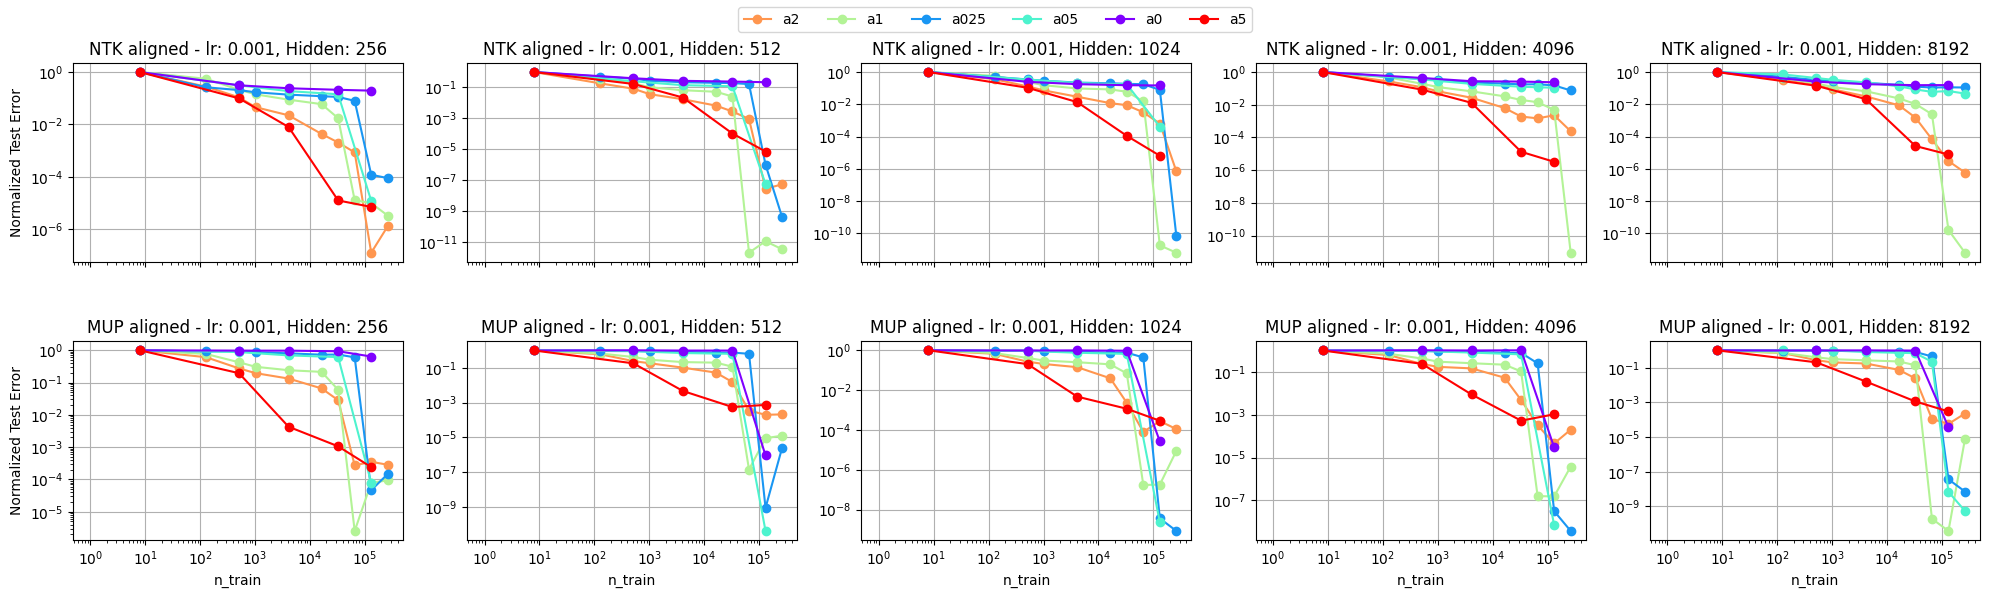

In [11]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl

# ======= USER SETTINGS =======
# Set the paths to your results directories
standard_results_directory = "/home/goring/TF_spectrum/results/results_correct_scaling/d30_hidden256_ntk_al_2702"
mup_results_directory = "/home/goring/TF_spectrum/results/results_correct_scaling/d30_hidden256_mup_al_2702"

# If you want to save the figure, specify a file name (e.g., "my_plot.png"); otherwise, leave as an empty string.
save_fig_path = ""  # e.g., "my_plot.png"

# Set to True to normalize all curves to 1 at the first point, False to use raw values
normalize_errors = True  # Toggle normalization on/off

# ======= LOAD RESULTS =======
def load_results(directory):
    """
    Load all JSON Lines files in the directory that match the pattern *_results_*.jsonl.
    Each line should be a JSON object corresponding to one experimental configuration.
    """
    pattern = os.path.join(directory, "results_*.jsonl")
    files = glob.glob(pattern)
    results = []
    for filename in files:
        with open(filename, "r") as f:
            for line in f:
                try:
                    data = json.loads(line)
                    results.append(data)
                except Exception as e:
                    print(f"Error parsing line in {filename}: {line}\nError: {e}")
    return results

# Load both sets of results
standard_results = load_results(standard_results_directory)
mup_results = load_results(mup_results_directory)

if not standard_results:
    print("No standard results loaded. Please check the directory path.")
if not mup_results:
    print("No MUP results loaded. Please check the directory path.")

# ======= FILTER FOR DEPTH 1 NETWORKS =======
standard_results_depth1 = [r for r in standard_results if r.get("depth") == 1]
mup_results_depth1 = [r for r in mup_results if r.get("depth") == 1]

# ======= IDENTIFY UNIQUE PARAMETERS =======
lr_set = set()
hidden_set = set()
dataset_set = set()

# Extract unique parameters from both standard and MUP results
for r in standard_results_depth1 + mup_results_depth1:
    try:
        lr_set.add(r["learning_rate"])
        hidden_set.add(r["hidden_size"])
        dataset_set.add(r["dataset_name"])
    except KeyError as e:
        print(f"Missing key {e} in result: {r}")
        continue

unique_lr = sorted(lr_set)
unique_hidden = sorted(hidden_set)
unique_dataset = sorted([d for d in dataset_set if d.startswith('a')])  # Filter for 'a' datasets

# ======= RAINBOW COLOR MAPPING =======
def create_dataset_colors(dataset_names):
    # Get only 'a' datasets
    a_datasets = [ds for ds in dataset_names if ds.startswith('a')]
    
    # Create color dictionary using rainbow colormap
    cmap = plt.get_cmap('rainbow')
    colors = {}
    
    # Define specific dataset order
    dataset_order = ['a0', 'a025', 'a05', 'a1', 'a2', 'a5']
    
    # Assign colors based on position in dataset_order
    for i, dataset in enumerate(dataset_order):
        if dataset in a_datasets:
            # Distribute colors evenly across the rainbow
            colors[dataset] = cmap(i / (len(dataset_order) - 1))
    
    # For any dataset not in our predefined list
    for dataset in a_datasets:
        if dataset not in colors:
            # Try to extract number and position it in the spectrum
            try:
                # For datasets like 'a3' that might not be in our list
                num = float(dataset[1:])
                # Position between 0 and 5 (assuming a0 to a5 range)
                position = min(1.0, max(0.0, num / 5.0))
                colors[dataset] = cmap(position)
            except ValueError:
                # Default for unparseable datasets
                colors[dataset] = cmap(0.5)  # Middle of the rainbow
    
    return colors

# Create color dictionary
dataset_colors = create_dataset_colors(unique_dataset)

# ======= GROUP DATA =======
# Function to group data by parameters
def group_results(results):
    grouped = {}
    for lr in unique_lr:
        grouped[lr] = {}
        for hs in unique_hidden:
            grouped[lr][hs] = {}
    
    for r in results:
        try:
            lr = r["learning_rate"]
            hs = r["hidden_size"]
            dataset = r["dataset_name"]
            n_train = r["n_train"]
            test_error = r["test_error"]  # Using final_train_error as per original code
        except KeyError as e:
            print(f"Skipping result due to missing key: {e}")
            continue
        
        if dataset not in unique_dataset:
            continue  # Skip datasets that aren't in the a0-a5 format
            
        if dataset not in grouped[lr][hs]:
            grouped[lr][hs][dataset] = {}
        if n_train not in grouped[lr][hs][dataset]:
            grouped[lr][hs][dataset][n_train] = []
        grouped[lr][hs][dataset][n_train].append(test_error)
    
    return grouped

# Group both sets of results
standard_grouped = group_results(standard_results_depth1)
mup_grouped = group_results(mup_results_depth1)

# ======= PLOT THE RESULTS =======
# Create a grid of subplots: 
# - Each column is a different hidden size
# - Each row pair is a learning rate (standard above, MUP below)
n_rows = 2 * len(unique_lr)  # Two rows per learning rate (standard + MUP)
n_cols = len(unique_hidden)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), sharex=True, sharey=False)

# Ensure axes is a 2D array
if n_rows == 1 and n_cols == 1:
    axes = np.array([[axes]])
elif n_rows == 1:
    axes = np.array([axes])
elif n_cols == 1:
    axes = np.array([[ax] for ax in axes])

# Create a dictionary to store legend handles
legend_handles = {}

for i, lr in enumerate(unique_lr):
    for j, hs in enumerate(unique_hidden):
        # Calculate row indices for standard and MUP plots
        standard_row = 2 * i
        mup_row = 2 * i + 1
        
        # Get the axes for standard and MUP plots
        ax_standard = axes[standard_row, j]
        ax_mup = axes[mup_row, j]
        
        # Standard plot
        data_dict = standard_grouped[lr][hs]
        if data_dict:
            for dataset, ntrain_dict in data_dict.items():
                n_train_sorted = sorted(ntrain_dict.keys())
                if not n_train_sorted:
                    continue
                
                x_vals = n_train_sorted
                y_means = []
                y_stds = []
                
                # Calculate means and standard deviations
                for n in n_train_sorted:
                    errors = ntrain_dict[n]
                    mean_error = sum(errors) / len(errors)
                    std_error = np.std(errors) if len(errors) > 1 else 0
                    y_means.append(mean_error)
                    y_stds.append(std_error)
                
                # Normalize errors if normalization is enabled
                first_mean = y_means[0] if y_means else 0
                if normalize_errors and y_means and first_mean > 0:
                    y_means = [err / first_mean for err in y_means]
                    y_stds = [std / first_mean for std in y_stds]
                
                # Get color from viridis map
                color = dataset_colors.get(dataset, 'blue')
                
                # Plot the line
                line = ax_standard.errorbar(
                    x_vals, y_means, yerr=y_stds,
                    linestyle='-', marker='o', color=color, 
                    label=f"{dataset}"
                )[0]
                
                # Store for legend
                legend_key = dataset
                if legend_key not in legend_handles:
                    legend_handles[legend_key] = line
        
        # MUP plot - FIXED VERSION WITH CONSISTENT NORMALIZATION
        data_dict = mup_grouped[lr][hs]
        if data_dict:
            for dataset, ntrain_dict in data_dict.items():
                n_train_sorted = sorted(ntrain_dict.keys())
                if not n_train_sorted:
                    continue
                
                x_vals = n_train_sorted
                y_means = []
                y_stds = []
                
                # Calculate means and standard deviations
                for n in n_train_sorted:
                    errors = ntrain_dict[n]
                    mean_error = sum(errors) / len(errors)
                    std_error = np.std(errors) if len(errors) > 1 else 0
                    y_means.append(mean_error)
                    y_stds.append(std_error)
                
                # Normalize errors if normalization is enabled - FIXED: now consistent with NTK plot
                first_mean = y_means[0] if y_means else 0
                if normalize_errors and y_means and first_mean > 0:
                    y_means = [err / first_mean for err in y_means]
                    y_stds = [std / first_mean for std in y_stds]
                
                # Get color from viridis map
                color = dataset_colors.get(dataset, 'blue')
                
                # Plot the line
                ax_mup.errorbar(
                    x_vals, y_means, yerr=y_stds,
                    linestyle='-', marker='o', color=color
                )
        
        # Set scales, labels, title for standard plot
        ax_standard.set_xscale("log")
        ax_standard.set_yscale("log")
        ax_standard.set_title(f"NTK aligned - lr: {lr}, Hidden: {hs}")
        ax_standard.grid(True)
        
        # Only add x-label to bottom row
        if i == len(unique_lr) - 1:
            ax_mup.set_xlabel("n_train")
        
        # Set y-axis label based on normalization
        if j == 0:
            y_label = "Normalized Test Error" if normalize_errors else "Test Error"
            ax_standard.set_ylabel(y_label)
            ax_mup.set_ylabel(y_label)
        
        # Set scales, labels, title for MUP plot
        ax_mup.set_xscale("log")
        ax_mup.set_yscale("log")
        ax_mup.set_title(f"MUP aligned - lr: {lr}, Hidden: {hs}")
        ax_mup.grid(True)

# Create a global legend above the subplots
fig.legend(
    legend_handles.values(), 
    legend_handles.keys(), 
    loc="upper center", 
    ncol=min(len(legend_handles), 6)
)

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(top=0.90, hspace=0.4)  # Make room for the legend and between rows

if save_fig_path:
    plt.savefig(save_fig_path)
    print("Figure saved to", save_fig_path)
else:
    plt.show()

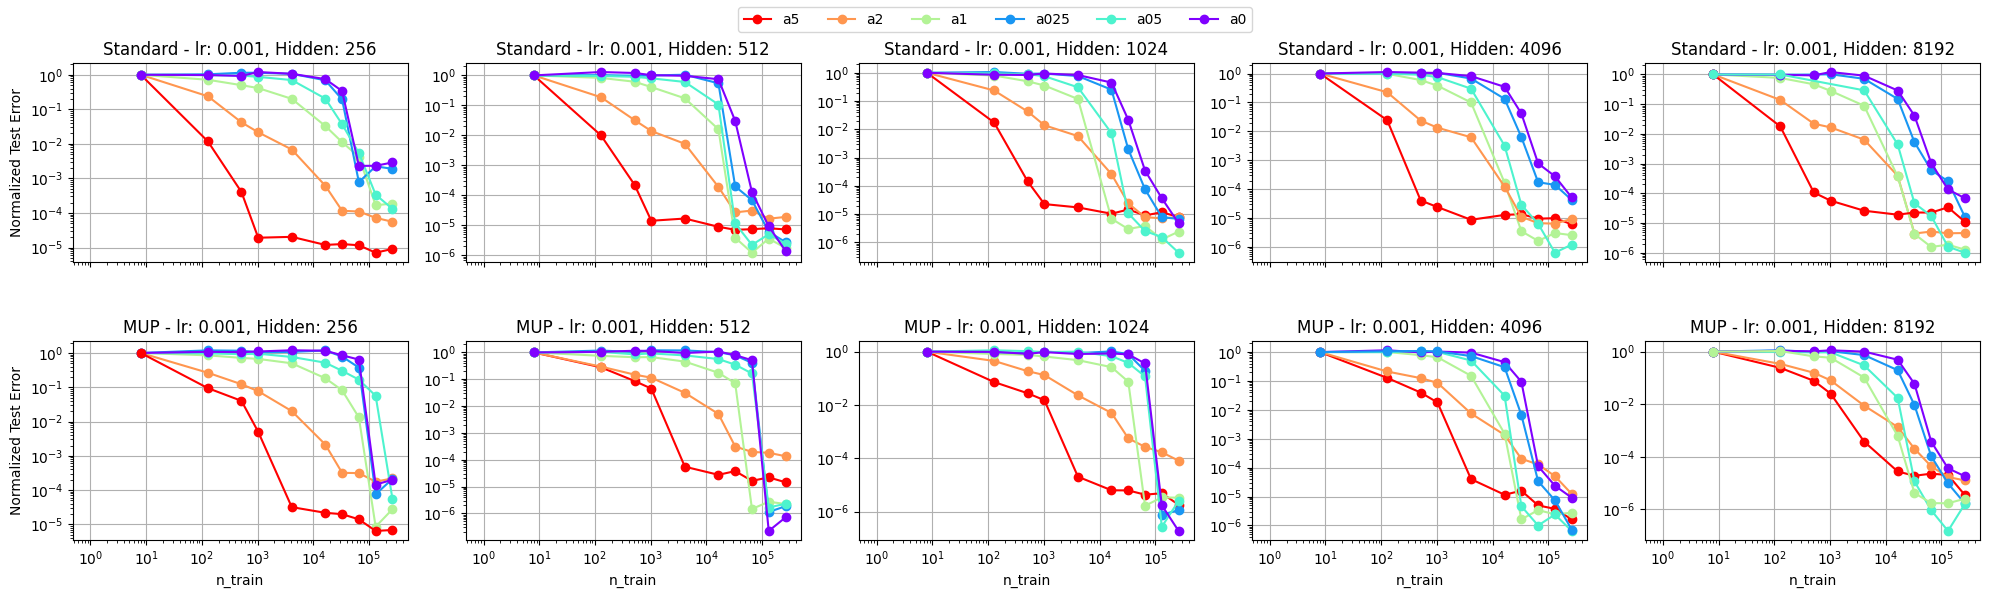

In [9]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl

# ======= USER SETTINGS =======
# Set the paths to your results directories
standard_results_directory = "/home/goring/TF_spectrum/results/results_correct_scaling/d10_hidden256_standard_2502"
mup_results_directory = "/home/goring/TF_spectrum/results/results_correct_scaling/d10_hidden256_mup_2502"

# If you want to save the figure, specify a file name (e.g., "my_plot.png"); otherwise, leave as an empty string.
save_fig_path = ""  # e.g., "my_plot.png"

# Set to True to normalize all curves to 1 at the first point, False to use raw values
normalize_errors = True  # Toggle normalization on/off

# ======= LOAD RESULTS =======
def load_results(directory):
    """
    Load all JSON Lines files in the directory that match the pattern *_results_*.jsonl.
    Each line should be a JSON object corresponding to one experimental configuration.
    """
    pattern = os.path.join(directory, "results_*.jsonl")
    files = glob.glob(pattern)
    results = []
    for filename in files:
        with open(filename, "r") as f:
            for line in f:
                try:
                    data = json.loads(line)
                    results.append(data)
                except Exception as e:
                    print(f"Error parsing line in {filename}: {line}\nError: {e}")
    return results

# Load both sets of results
standard_results = load_results(standard_results_directory)
mup_results = load_results(mup_results_directory)

if not standard_results:
    print("No standard results loaded. Please check the directory path.")
if not mup_results:
    print("No MUP results loaded. Please check the directory path.")

# ======= FILTER FOR DEPTH 1 NETWORKS =======
standard_results_depth1 = [r for r in standard_results if r.get("depth") == 1]
mup_results_depth1 = [r for r in mup_results if r.get("depth") == 1]

# ======= IDENTIFY UNIQUE PARAMETERS =======
lr_set = set()
hidden_set = set()
dataset_set = set()

# Extract unique parameters from both standard and MUP results
for r in standard_results_depth1 + mup_results_depth1:
    try:
        lr_set.add(r["learning_rate"])
        hidden_set.add(r["hidden_size"])
        dataset_set.add(r["dataset_name"])
    except KeyError as e:
        print(f"Missing key {e} in result: {r}")
        continue

unique_lr = sorted(lr_set)
unique_hidden = sorted(hidden_set)
unique_dataset = sorted([d for d in dataset_set if d.startswith('a')])  # Filter for 'a' datasets

# ======= RAINBOW COLOR MAPPING =======
def create_dataset_colors(dataset_names):
    # Get only 'a' datasets
    a_datasets = [ds for ds in dataset_names if ds.startswith('a')]
    
    # Create color dictionary using rainbow colormap
    cmap = plt.get_cmap('rainbow')
    colors = {}
    
    # Define specific dataset order
    dataset_order = ['a0', 'a025', 'a05', 'a1', 'a2', 'a5']
    
    # Assign colors based on position in dataset_order
    for i, dataset in enumerate(dataset_order):
        if dataset in a_datasets:
            # Distribute colors evenly across the rainbow
            colors[dataset] = cmap(i / (len(dataset_order) - 1))
    
    # For any dataset not in our predefined list
    for dataset in a_datasets:
        if dataset not in colors:
            # Try to extract number and position it in the spectrum
            try:
                # For datasets like 'a3' that might not be in our list
                num = float(dataset[1:])
                # Position between 0 and 5 (assuming a0 to a5 range)
                position = min(1.0, max(0.0, num / 5.0))
                colors[dataset] = cmap(position)
            except ValueError:
                # Default for unparseable datasets
                colors[dataset] = cmap(0.5)  # Middle of the rainbow
    
    return colors

# Create color dictionary
dataset_colors = create_dataset_colors(unique_dataset)

# ======= GROUP DATA =======
# Function to group data by parameters
def group_results(results):
    grouped = {}
    for lr in unique_lr:
        grouped[lr] = {}
        for hs in unique_hidden:
            grouped[lr][hs] = {}
    
    for r in results:
        try:
            lr = r["learning_rate"]
            hs = r["hidden_size"]
            dataset = r["dataset_name"]
            n_train = r["n_train"]
            test_error = r["test_error"]  # Using final_train_error as per original code
        except KeyError as e:
            print(f"Skipping result due to missing key: {e}")
            continue
        
        if dataset not in unique_dataset:
            continue  # Skip datasets that aren't in the a0-a5 format
            
        if dataset not in grouped[lr][hs]:
            grouped[lr][hs][dataset] = {}
        if n_train not in grouped[lr][hs][dataset]:
            grouped[lr][hs][dataset][n_train] = []
        grouped[lr][hs][dataset][n_train].append(test_error)
    
    return grouped

# Group both sets of results
standard_grouped = group_results(standard_results_depth1)
mup_grouped = group_results(mup_results_depth1)

# ======= PLOT THE RESULTS =======
# Create a grid of subplots: 
# - Each column is a different hidden size
# - Each row pair is a learning rate (standard above, MUP below)
n_rows = 2 * len(unique_lr)  # Two rows per learning rate (standard + MUP)
n_cols = len(unique_hidden)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), sharex=True, sharey=False)

# Ensure axes is a 2D array
if n_rows == 1 and n_cols == 1:
    axes = np.array([[axes]])
elif n_rows == 1:
    axes = np.array([axes])
elif n_cols == 1:
    axes = np.array([[ax] for ax in axes])

# Create a dictionary to store legend handles
legend_handles = {}

for i, lr in enumerate(unique_lr):
    for j, hs in enumerate(unique_hidden):
        # Calculate row indices for standard and MUP plots
        standard_row = 2 * i
        mup_row = 2 * i + 1
        
        # Get the axes for standard and MUP plots
        ax_standard = axes[standard_row, j]
        ax_mup = axes[mup_row, j]
        
        # Standard plot
        data_dict = standard_grouped[lr][hs]
        if data_dict:
            for dataset, ntrain_dict in data_dict.items():
                n_train_sorted = sorted(ntrain_dict.keys())
                if not n_train_sorted:
                    continue
                
                x_vals = n_train_sorted
                y_means = []
                y_stds = []
                
                # Calculate means and standard deviations
                for n in n_train_sorted:
                    errors = ntrain_dict[n]
                    mean_error = sum(errors) / len(errors)
                    std_error = np.std(errors) if len(errors) > 1 else 0
                    y_means.append(mean_error)
                    y_stds.append(std_error)
                
                # Normalize errors if normalization is enabled
                first_mean = y_means[0] if y_means else 0
                if normalize_errors and y_means and first_mean > 0:
                    y_means = [err / first_mean for err in y_means]
                    y_stds = [std / first_mean for std in y_stds]
                
                # Get color from viridis map
                color = dataset_colors.get(dataset, 'blue')
                
                # Plot the line
                line = ax_standard.errorbar(
                    x_vals, y_means, yerr=y_stds,
                    linestyle='-', marker='o', color=color, 
                    label=f"{dataset}"
                )[0]
                
                # Store for legend
                legend_key = dataset
                if legend_key not in legend_handles:
                    legend_handles[legend_key] = line
        
        # MUP plot - FIXED VERSION WITH CONSISTENT NORMALIZATION
        data_dict = mup_grouped[lr][hs]
        if data_dict:
            for dataset, ntrain_dict in data_dict.items():
                n_train_sorted = sorted(ntrain_dict.keys())
                if not n_train_sorted:
                    continue
                
                x_vals = n_train_sorted
                y_means = []
                y_stds = []
                
                # Calculate means and standard deviations
                for n in n_train_sorted:
                    errors = ntrain_dict[n]
                    mean_error = sum(errors) / len(errors)
                    std_error = np.std(errors) if len(errors) > 1 else 0
                    y_means.append(mean_error)
                    y_stds.append(std_error)
                
                # Normalize errors if normalization is enabled - FIXED: now consistent with NTK plot
                first_mean = y_means[0] if y_means else 0
                if normalize_errors and y_means and first_mean > 0:
                    y_means = [err / first_mean for err in y_means]
                    y_stds = [std / first_mean for std in y_stds]
                
                # Get color from viridis map
                color = dataset_colors.get(dataset, 'blue')
                
                # Plot the line
                ax_mup.errorbar(
                    x_vals, y_means, yerr=y_stds,
                    linestyle='-', marker='o', color=color
                )
        
        # Set scales, labels, title for standard plot
        ax_standard.set_xscale("log")
        ax_standard.set_yscale("log")
        ax_standard.set_title(f"Standard - lr: {lr}, Hidden: {hs}")
        ax_standard.grid(True)
        
        # Only add x-label to bottom row
        if i == len(unique_lr) - 1:
            ax_mup.set_xlabel("n_train")
        
        # Set y-axis label based on normalization
        if j == 0:
            y_label = "Normalized Test Error" if normalize_errors else "Test Error"
            ax_standard.set_ylabel(y_label)
            ax_mup.set_ylabel(y_label)
        
        # Set scales, labels, title for MUP plot
        ax_mup.set_xscale("log")
        ax_mup.set_yscale("log")
        ax_mup.set_title(f"MUP - lr: {lr}, Hidden: {hs}")
        ax_mup.grid(True)

# Create a global legend above the subplots
fig.legend(
    legend_handles.values(), 
    legend_handles.keys(), 
    loc="upper center", 
    ncol=min(len(legend_handles), 6)
)

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(top=0.90, hspace=0.4)  # Make room for the legend and between rows

if save_fig_path:
    plt.savefig(save_fig_path)
    print("Figure saved to", save_fig_path)
else:
    plt.show()

Comparing learning rates: [0.0005, 0.001]


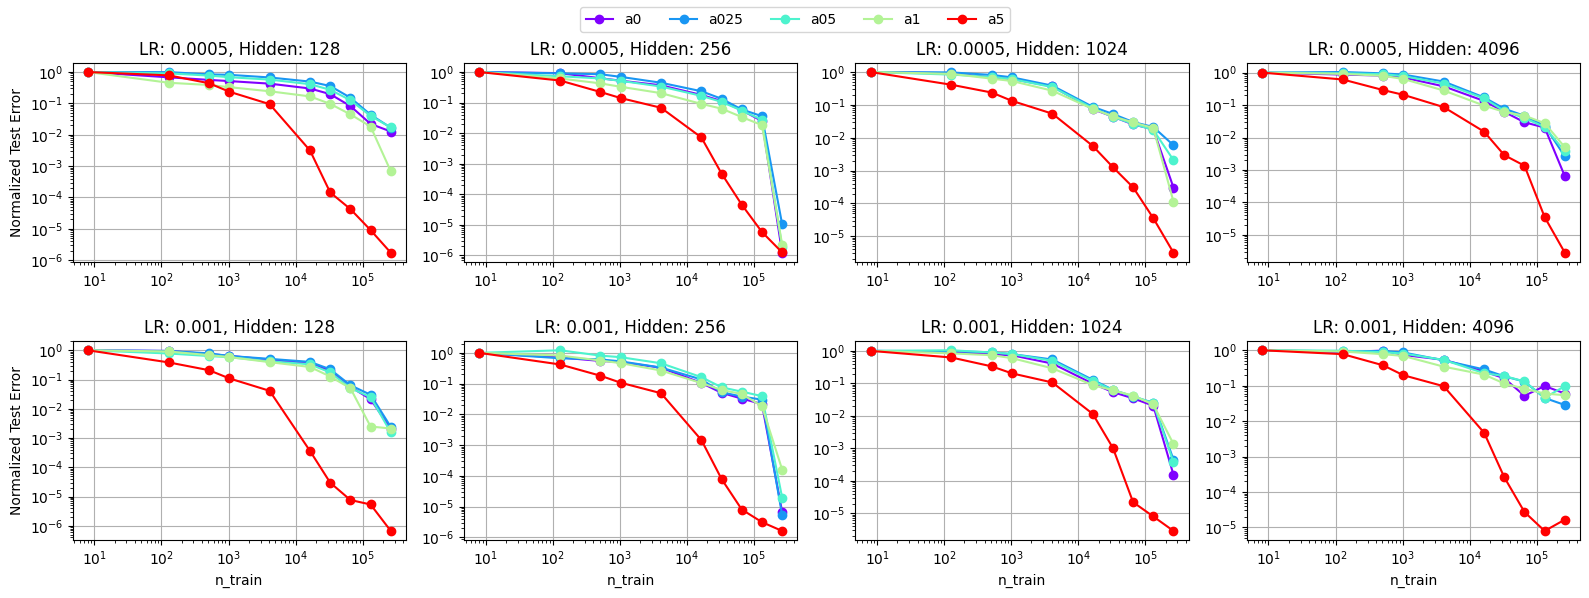

In [3]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl

# ======= USER SETTINGS =======
# Set the paths to your results directories
results_directory = "/home/goring/TF_spectrum/results/results_correct_scaling/d16_uniform_hidden128_d2_standard_0103"

# If you want to save the figure, specify a file name (e.g., "my_plot.png"); otherwise, leave as an empty string.
save_fig_path = ""  # e.g., "my_plot.png"

# Set to True to normalize all curves to 1 at the first point, False to use raw values
normalize_errors = True  # Toggle normalization on/off

# ======= LOAD RESULTS =======
def load_results(directory):
    """
    Load all JSON Lines files in the directory that match the pattern *_results_*.jsonl.
    Each line should be a JSON object corresponding to one experimental configuration.
    """
    pattern = os.path.join(directory, "results_*.jsonl")
    files = glob.glob(pattern)
    results = []
    for filename in files:
        with open(filename, "r") as f:
            for line in f:
                try:
                    data = json.loads(line)
                    results.append(data)
                except Exception as e:
                    print(f"Error parsing line in {filename}: {line}\nError: {e}")
    return results

# Load results
all_results = load_results(results_directory)

if not all_results:
    print("No results loaded. Please check the directory path.")

# ======= FILTER FOR SPECIFIC NETWORKS =======
# We'll filter by depth if needed
filtered_results = [r for r in all_results if r.get("depth") == 2]  # Using depth=2 as mentioned in the example

# ======= IDENTIFY UNIQUE PARAMETERS =======
lr_set = set()
hidden_set = set()
dataset_set = set()

# Extract unique parameters from results
for r in filtered_results:
    try:
        lr_set.add(r["learning_rate"])
        hidden_set.add(r["hidden_size"])
        dataset_set.add(r["dataset_name"])
    except KeyError as e:
        print(f"Missing key {e} in result: {r}")
        continue

unique_lr = sorted(lr_set)
unique_hidden = sorted(hidden_set)
unique_dataset = sorted([d for d in dataset_set if d.startswith('a')])  # Filter for 'a' datasets

# We'll compare the first two learning rates
if len(unique_lr) >= 2:
    learning_rates_to_compare = unique_lr[:2]
    print(f"Comparing learning rates: {learning_rates_to_compare}")
else:
    learning_rates_to_compare = unique_lr
    print(f"Only one learning rate available: {learning_rates_to_compare}")

# ======= RAINBOW COLOR MAPPING =======
def create_dataset_colors(dataset_names):
    # Get only 'a' datasets
    a_datasets = [ds for ds in dataset_names if ds.startswith('a')]
    
    # Create color dictionary using rainbow colormap
    cmap = plt.get_cmap('rainbow')
    colors = {}
    
    # Define specific dataset order
    dataset_order = ['a0', 'a025', 'a05', 'a1', 'a2', 'a5']
    
    # Assign colors based on position in dataset_order
    for i, dataset in enumerate(dataset_order):
        if dataset in a_datasets:
            # Distribute colors evenly across the rainbow
            colors[dataset] = cmap(i / (len(dataset_order) - 1))
    
    # For any dataset not in our predefined list
    for dataset in a_datasets:
        if dataset not in colors:
            # Try to extract number and position it in the spectrum
            try:
                # For datasets like 'a3' that might not be in our list
                num = float(dataset[1:])
                # Position between 0 and 5 (assuming a0 to a5 range)
                position = min(1.0, max(0.0, num / 5.0))
                colors[dataset] = cmap(position)
            except ValueError:
                # Default for unparseable datasets
                colors[dataset] = cmap(0.5)  # Middle of the rainbow
    
    return colors

# Create color dictionary
dataset_colors = create_dataset_colors(unique_dataset)

# ======= GROUP DATA =======
# Function to group data by parameters
def group_results(results):
    grouped = {}
    for lr in unique_lr:
        grouped[lr] = {}
        for hs in unique_hidden:
            grouped[lr][hs] = {}
    
    for r in results:
        try:
            lr = r["learning_rate"]
            hs = r["hidden_size"]
            dataset = r["dataset_name"]
            n_train = r["n_train"]
            test_error = r["test_error"]
        except KeyError as e:
            print(f"Skipping result due to missing key: {e}")
            continue
        
        if dataset not in unique_dataset:
            continue  # Skip datasets that aren't in the a0-a5 format
            
        if dataset not in grouped[lr][hs]:
            grouped[lr][hs][dataset] = {}
        if n_train not in grouped[lr][hs][dataset]:
            grouped[lr][hs][dataset][n_train] = []
        grouped[lr][hs][dataset][n_train].append(test_error)
    
    return grouped

# Group results
grouped_results = group_results(filtered_results)

# ======= PLOT THE RESULTS =======
# Create a grid of subplots: 
# - Each column is a different hidden size
# - Each row is a learning rate
n_rows = len(learning_rates_to_compare)
n_cols = len(unique_hidden)

# Catch the case where there's only one hidden size to prevent 1D array issues
if n_cols == 1:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6, 4 * n_rows), squeeze=False)
else:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), squeeze=False)

# Create a dictionary to store legend handles
legend_handles = {}

for i, lr in enumerate(learning_rates_to_compare):
    for j, hs in enumerate(unique_hidden):
        # Get the appropriate axis
        ax = axes[i, j]
        
        # Plot data for this learning rate and hidden size
        data_dict = grouped_results[lr][hs]
        if data_dict:
            for dataset, ntrain_dict in data_dict.items():
                n_train_sorted = sorted(ntrain_dict.keys())
                if not n_train_sorted:
                    continue
                
                x_vals = n_train_sorted
                y_means = []
                y_stds = []
                
                # Calculate means and standard deviations
                for n in n_train_sorted:
                    errors = ntrain_dict[n]
                    mean_error = sum(errors) / len(errors)
                    std_error = np.std(errors) if len(errors) > 1 else 0
                    y_means.append(mean_error)
                    y_stds.append(std_error)
                
                # Normalize errors if normalization is enabled
                first_mean = y_means[0] if y_means else 0
                if normalize_errors and y_means and first_mean > 0:
                    y_means = [err / first_mean for err in y_means]
                    y_stds = [std / first_mean for std in y_stds]
                
                # Get color from dataset colors
                color = dataset_colors.get(dataset, 'blue')
                
                # Plot the line
                line = ax.errorbar(
                    x_vals, y_means, yerr=y_stds,
                    linestyle='-', marker='o', color=color, 
                    label=f"{dataset}"
                )[0]
                
                # Store for legend
                legend_key = dataset
                if legend_key not in legend_handles:
                    legend_handles[legend_key] = line
        
        # Set scales, labels, title
        ax.set_xscale("log")
        #ax.set_yscale("log")
        # Set y-scale to log if normalizing (to see power laws better)
        if normalize_errors:
            ax.set_yscale("log")
        
        ax.set_title(f"LR: {lr}, Hidden: {hs}")
        ax.grid(True)
        
        # Only add x-label to bottom row
        if i == len(learning_rates_to_compare) - 1:
            ax.set_xlabel("n_train")
        
        # Add y-label to leftmost column
        if j == 0:
            y_label = "Normalized Test Error" if normalize_errors else "Test Error"
            ax.set_ylabel(y_label)

# Create a global legend above the subplots only if we have handles
if legend_handles:
    fig.legend(
        list(legend_handles.values()), 
        list(legend_handles.keys()), 
        loc="upper center", 
        ncol=min(len(legend_handles), 6)
    )

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(top=0.90, hspace=0.4)  # Make room for the legend and between rows

if save_fig_path:
    plt.savefig(save_fig_path)
    print("Figure saved to", save_fig_path)
else:
    plt.show()

Comparing learning rates: [0.0005, 0.001]


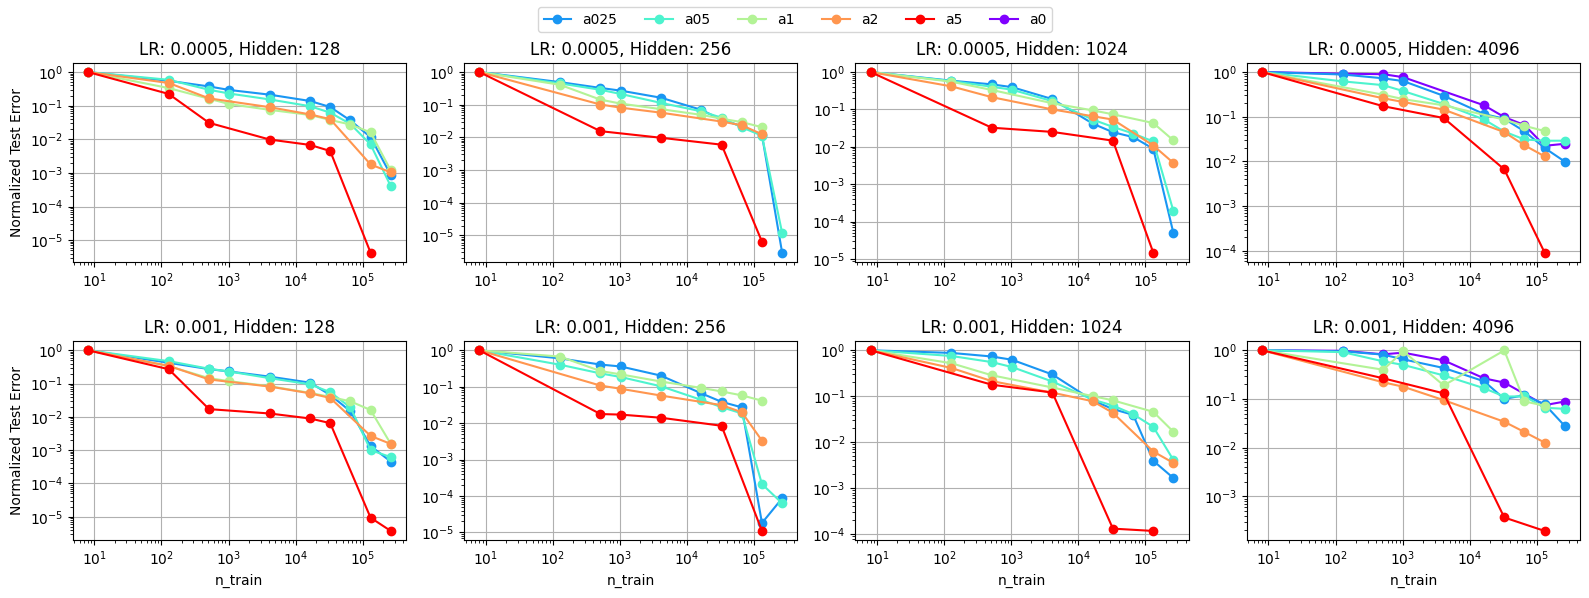

In [1]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl

# ======= USER SETTINGS =======
# Set the paths to your results directories
results_directory = "/home/goring/TF_spectrum/results/results_correct_scaling/d16_normal_hidden128_d2_standard_orthogonal_0203"

# If you want to save the figure, specify a file name (e.g., "my_plot.png"); otherwise, leave as an empty string.
save_fig_path = ""  # e.g., "my_plot.png"

# Set to True to normalize all curves to 1 at the first point, False to use raw values
normalize_errors = True  # Toggle normalization on/off

# ======= LOAD RESULTS =======
def load_results(directory):
    """
    Load all JSON Lines files in the directory that match the pattern *_results_*.jsonl.
    Each line should be a JSON object corresponding to one experimental configuration.
    """
    pattern = os.path.join(directory, "results_*.jsonl")
    files = glob.glob(pattern)
    results = []
    for filename in files:
        with open(filename, "r") as f:
            for line in f:
                try:
                    data = json.loads(line)
                    results.append(data)
                except Exception as e:
                    print(f"Error parsing line in {filename}: {line}\nError: {e}")
    return results

# Load results
all_results = load_results(results_directory)

if not all_results:
    print("No results loaded. Please check the directory path.")

# ======= FILTER FOR SPECIFIC NETWORKS =======
# We'll filter by depth if needed
filtered_results = [r for r in all_results if r.get("depth") == 2]  # Using depth=2 as mentioned in the example

# ======= IDENTIFY UNIQUE PARAMETERS =======
lr_set = set()
hidden_set = set()
dataset_set = set()

# Extract unique parameters from results
for r in filtered_results:
    try:
        lr_set.add(r["learning_rate"])
        hidden_set.add(r["hidden_size"])
        dataset_set.add(r["dataset_name"])
    except KeyError as e:
        print(f"Missing key {e} in result: {r}")
        continue

unique_lr = sorted(lr_set)
unique_hidden = sorted(hidden_set)
unique_dataset = sorted([d for d in dataset_set if d.startswith('a')])  # Filter for 'a' datasets

# We'll compare the first two learning rates
if len(unique_lr) >= 2:
    learning_rates_to_compare = unique_lr[:2]
    print(f"Comparing learning rates: {learning_rates_to_compare}")
else:
    learning_rates_to_compare = unique_lr
    print(f"Only one learning rate available: {learning_rates_to_compare}")

# ======= RAINBOW COLOR MAPPING =======
def create_dataset_colors(dataset_names):
    # Get only 'a' datasets
    a_datasets = [ds for ds in dataset_names if ds.startswith('a')]
    
    # Create color dictionary using rainbow colormap
    cmap = plt.get_cmap('rainbow')
    colors = {}
    
    # Define specific dataset order
    dataset_order = ['a0', 'a025', 'a05', 'a1', 'a2', 'a5']
    
    # Assign colors based on position in dataset_order
    for i, dataset in enumerate(dataset_order):
        if dataset in a_datasets:
            # Distribute colors evenly across the rainbow
            colors[dataset] = cmap(i / (len(dataset_order) - 1))
    
    # For any dataset not in our predefined list
    for dataset in a_datasets:
        if dataset not in colors:
            # Try to extract number and position it in the spectrum
            try:
                # For datasets like 'a3' that might not be in our list
                num = float(dataset[1:])
                # Position between 0 and 5 (assuming a0 to a5 range)
                position = min(1.0, max(0.0, num / 5.0))
                colors[dataset] = cmap(position)
            except ValueError:
                # Default for unparseable datasets
                colors[dataset] = cmap(0.5)  # Middle of the rainbow
    
    return colors

# Create color dictionary
dataset_colors = create_dataset_colors(unique_dataset)

# ======= GROUP DATA =======
# Function to group data by parameters
def group_results(results):
    grouped = {}
    for lr in unique_lr:
        grouped[lr] = {}
        for hs in unique_hidden:
            grouped[lr][hs] = {}
    
    for r in results:
        try:
            lr = r["learning_rate"]
            hs = r["hidden_size"]
            dataset = r["dataset_name"]
            n_train = r["n_train"]
            test_error = r["test_error"]
        except KeyError as e:
            print(f"Skipping result due to missing key: {e}")
            continue
        
        if dataset not in unique_dataset:
            continue  # Skip datasets that aren't in the a0-a5 format
            
        if dataset not in grouped[lr][hs]:
            grouped[lr][hs][dataset] = {}
        if n_train not in grouped[lr][hs][dataset]:
            grouped[lr][hs][dataset][n_train] = []
        grouped[lr][hs][dataset][n_train].append(test_error)
    
    return grouped

# Group results
grouped_results = group_results(filtered_results)

# ======= PLOT THE RESULTS =======
# Create a grid of subplots: 
# - Each column is a different hidden size
# - Each row is a learning rate
n_rows = len(learning_rates_to_compare)
n_cols = len(unique_hidden)

# Catch the case where there's only one hidden size to prevent 1D array issues
if n_cols == 1:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6, 4 * n_rows), squeeze=False)
else:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), squeeze=False)

# Create a dictionary to store legend handles
legend_handles = {}

for i, lr in enumerate(learning_rates_to_compare):
    for j, hs in enumerate(unique_hidden):
        # Get the appropriate axis
        ax = axes[i, j]
        
        # Plot data for this learning rate and hidden size
        data_dict = grouped_results[lr][hs]
        if data_dict:
            for dataset, ntrain_dict in data_dict.items():
                n_train_sorted = sorted(ntrain_dict.keys())
                if not n_train_sorted:
                    continue
                
                x_vals = n_train_sorted
                y_means = []
                y_stds = []
                
                # Calculate means and standard deviations
                for n in n_train_sorted:
                    errors = ntrain_dict[n]
                    mean_error = sum(errors) / len(errors)
                    std_error = np.std(errors) if len(errors) > 1 else 0
                    y_means.append(mean_error)
                    y_stds.append(std_error)
                
                # Normalize errors if normalization is enabled
                first_mean = y_means[0] if y_means else 0
                if normalize_errors and y_means and first_mean > 0:
                    y_means = [err / first_mean for err in y_means]
                    y_stds = [std / first_mean for std in y_stds]
                
                # Get color from dataset colors
                color = dataset_colors.get(dataset, 'blue')
                
                # Plot the line
                line = ax.errorbar(
                    x_vals, y_means, yerr=y_stds,
                    linestyle='-', marker='o', color=color, 
                    label=f"{dataset}"
                )[0]
                
                # Store for legend
                legend_key = dataset
                if legend_key not in legend_handles:
                    legend_handles[legend_key] = line
        
        # Set scales, labels, title
        ax.set_xscale("log")
        #ax.set_yscale("log")
        # Set y-scale to log if normalizing (to see power laws better)
        if normalize_errors:
            ax.set_yscale("log")
        
        ax.set_title(f"LR: {lr}, Hidden: {hs}")
        ax.grid(True)
        
        # Only add x-label to bottom row
        if i == len(learning_rates_to_compare) - 1:
            ax.set_xlabel("n_train")
        
        # Add y-label to leftmost column
        if j == 0:
            y_label = "Normalized Test Error" if normalize_errors else "Test Error"
            ax.set_ylabel(y_label)

# Create a global legend above the subplots only if we have handles
if legend_handles:
    fig.legend(
        list(legend_handles.values()), 
        list(legend_handles.keys()), 
        loc="upper center", 
        ncol=min(len(legend_handles), 6)
    )

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(top=0.90, hspace=0.4)  # Make room for the legend and between rows

if save_fig_path:
    plt.savefig(save_fig_path)
    print("Figure saved to", save_fig_path)
else:
    plt.show()

Comparing learning rates: [0.0001, 0.001]
Figure saved to d50_normal_hidden10_plot.png


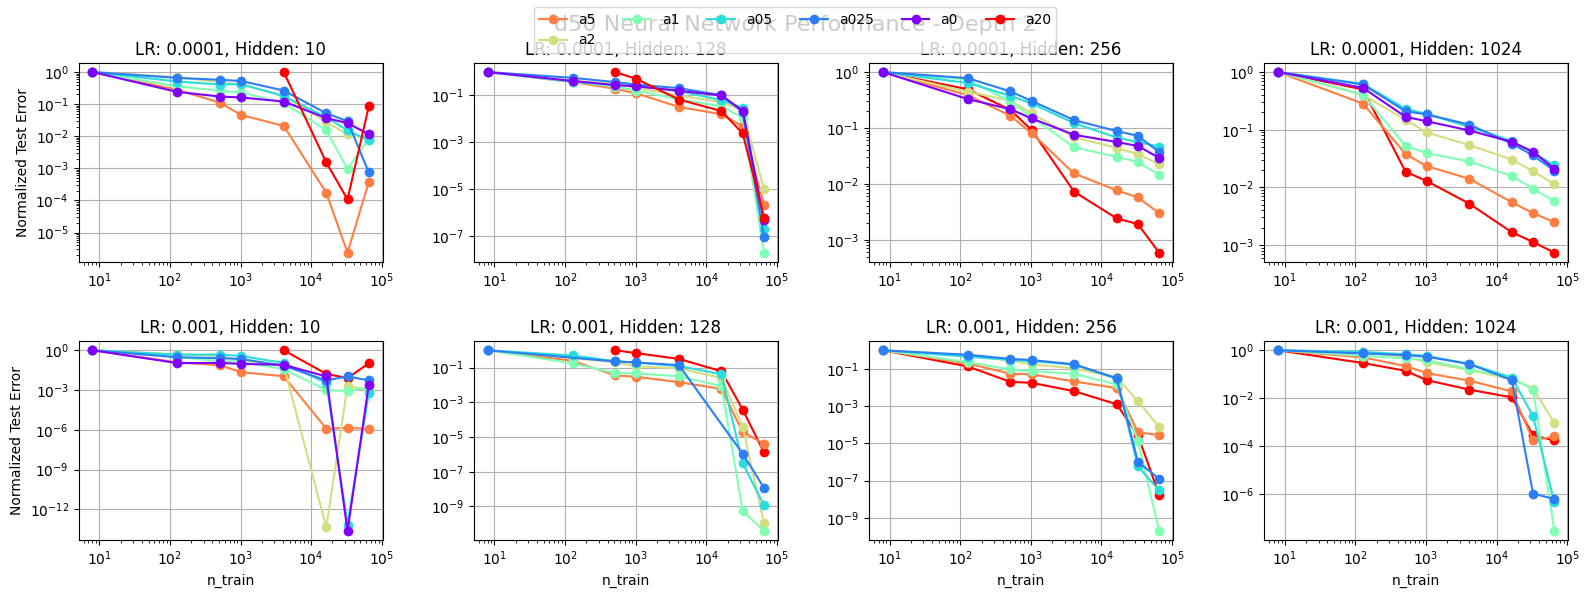

In [4]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl

# ======= USER SETTINGS =======
# Set the path to match the experiment name from the training script
results_directory = "/home/goring/TF_spectrum/results/results_correct_scaling/d50_normal_hidden10_d2_standard_0203"

# If you want to save the figure, specify a file name (e.g., "my_plot.png"); otherwise, leave as an empty string.
save_fig_path = "d50_normal_hidden10_plot.png"  # Set a filename to save the figure

# Set to True to normalize all curves to 1 at the first point, False to use raw values
normalize_errors = True  # Toggle normalization on/off

# ======= LOAD RESULTS =======
def load_results(directory):
    """
    Load all JSON Lines files in the directory that match the pattern *_results_*.jsonl.
    Each line should be a JSON object corresponding to one experimental configuration.
    """
    pattern = os.path.join(directory, "results_*.jsonl")
    files = glob.glob(pattern)
    results = []
    for filename in files:
        with open(filename, "r") as f:
            for line in f:
                try:
                    data = json.loads(line)
                    results.append(data)
                except Exception as e:
                    print(f"Error parsing line in {filename}: {line}\nError: {e}")
    return results

# Load results
all_results = load_results(results_directory)

if not all_results:
    print("No results loaded. Please check the directory path.")

# ======= FILTER FOR SPECIFIC NETWORKS =======
# We'll filter by depth=2 as specified in the training script
filtered_results = [r for r in all_results if r.get("depth") == 2]

# ======= IDENTIFY UNIQUE PARAMETERS =======
lr_set = set()
hidden_set = set()
dataset_set = set()

# Extract unique parameters from results
for r in filtered_results:
    try:
        lr_set.add(r["learning_rate"])
        hidden_set.add(r["hidden_size"])
        dataset_set.add(r["dataset_name"])
    except KeyError as e:
        print(f"Missing key {e} in result: {r}")
        continue

# Use the unique values found in the results
unique_lr = sorted(lr_set)  # Should contain [0.0001, 0.001, 0.01]
unique_hidden = sorted(hidden_set)  # Should contain [10, 128, 256, 1024]
unique_dataset = sorted([d for d in dataset_set if d.startswith('a')])  # Should contain ["a20","a5","a2","a1","a05","a025","a0"]

# Select top 2 learning rates for comparison (or use a specific subset)
# You can modify this to select specific learning rates if needed
if len(unique_lr) >= 2:
    learning_rates_to_compare = unique_lr[:2]
    print(f"Comparing learning rates: {learning_rates_to_compare}")
else:
    learning_rates_to_compare = unique_lr
    print(f"Only one learning rate available: {learning_rates_to_compare}")

# ======= RAINBOW COLOR MAPPING =======
def create_dataset_colors(dataset_names):
    # Get only 'a' datasets
    a_datasets = [ds for ds in dataset_names if ds.startswith('a')]
    
    # Create color dictionary using rainbow colormap
    cmap = plt.get_cmap('rainbow')
    colors = {}
    
    # Define specific dataset order to match the training dataset names
    dataset_order = ['a0', 'a025', 'a05', 'a1', 'a2', 'a5', 'a20']
    
    # Assign colors based on position in dataset_order
    for i, dataset in enumerate(dataset_order):
        if dataset in a_datasets:
            # Distribute colors evenly across the rainbow
            colors[dataset] = cmap(i / (len(dataset_order) - 1))
    
    # For any dataset not in our predefined list
    for dataset in a_datasets:
        if dataset not in colors:
            # Try to extract number and position it in the spectrum
            try:
                # For datasets like 'a3' that might not be in our list
                num = float(dataset[1:])
                # Position between 0 and 20 (assuming a0 to a20 range)
                position = min(1.0, max(0.0, num / 20.0))
                colors[dataset] = cmap(position)
            except ValueError:
                # Default for unparseable datasets
                colors[dataset] = cmap(0.5)  # Middle of the rainbow
    
    return colors

# Create color dictionary
dataset_colors = create_dataset_colors(unique_dataset)

# ======= GROUP DATA =======
# Function to group data by parameters
def group_results(results):
    grouped = {}
    for lr in unique_lr:
        grouped[lr] = {}
        for hs in unique_hidden:
            grouped[lr][hs] = {}
    
    for r in results:
        try:
            lr = r["learning_rate"]
            hs = r["hidden_size"]
            dataset = r["dataset_name"]
            n_train = r["n_train"]
            test_error = r["test_error"]
        except KeyError as e:
            print(f"Skipping result due to missing key: {e}")
            continue
        
        if dataset not in unique_dataset:
            continue  # Skip datasets that aren't in the a0-a20 format
            
        if dataset not in grouped[lr][hs]:
            grouped[lr][hs][dataset] = {}
        if n_train not in grouped[lr][hs][dataset]:
            grouped[lr][hs][dataset][n_train] = []
        grouped[lr][hs][dataset][n_train].append(test_error)
    
    return grouped

# Group results
grouped_results = group_results(filtered_results)

# ======= PLOT THE RESULTS =======
# Create a grid of subplots: 
# - Each column is a different hidden size
# - Each row is a learning rate
n_rows = len(learning_rates_to_compare)
n_cols = len(unique_hidden)

# Adjust figure size based on number of subplots
if n_cols == 1:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6, 4 * n_rows), squeeze=False)
else:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), squeeze=False)

# Create a dictionary to store legend handles
legend_handles = {}

for i, lr in enumerate(learning_rates_to_compare):
    for j, hs in enumerate(unique_hidden):
        # Get the appropriate axis
        ax = axes[i, j]
        
        # Plot data for this learning rate and hidden size
        data_dict = grouped_results[lr][hs]
        if data_dict:
            for dataset, ntrain_dict in data_dict.items():
                n_train_sorted = sorted(ntrain_dict.keys())
                if not n_train_sorted:
                    continue
                
                x_vals = n_train_sorted
                y_means = []
                y_stds = []
                
                # Calculate means and standard deviations
                for n in n_train_sorted:
                    errors = ntrain_dict[n]
                    mean_error = sum(errors) / len(errors)
                    std_error = np.std(errors) if len(errors) > 1 else 0
                    y_means.append(mean_error)
                    y_stds.append(std_error)
                
                # Normalize errors if normalization is enabled
                first_mean = y_means[0] if y_means else 0
                if normalize_errors and y_means and first_mean > 0:
                    y_means = [err / first_mean for err in y_means]
                    y_stds = [std / first_mean for std in y_stds]
                
                # Get color from dataset colors
                color = dataset_colors.get(dataset, 'blue')
                
                # Plot the line
                line = ax.errorbar(
                    x_vals, y_means, yerr=y_stds,
                    linestyle='-', marker='o', color=color, 
                    label=f"{dataset}"
                )[0]
                
                # Store for legend
                legend_key = dataset
                if legend_key not in legend_handles:
                    legend_handles[legend_key] = line
        
        # Set scales, labels, title
        ax.set_xscale("log")
        # Set y-scale to log if normalizing (to see power laws better)
        if normalize_errors:
            ax.set_yscale("log")
        
        ax.set_title(f"LR: {lr}, Hidden: {hs}")
        ax.grid(True)
        
        # Only add x-label to bottom row
        if i == len(learning_rates_to_compare) - 1:
            ax.set_xlabel("n_train")
        
        # Add y-label to leftmost column
        if j == 0:
            y_label = "Normalized Test Error" if normalize_errors else "Test Error"
            ax.set_ylabel(y_label)

# Create a global legend above the subplots only if we have handles
if legend_handles:
    fig.legend(
        list(legend_handles.values()), 
        list(legend_handles.keys()), 
        loc="upper center", 
        ncol=min(len(legend_handles), 6)
    )

# Add a title with experiment information
plt.suptitle(f"d50 Neural Network Performance - Depth 2", fontsize=16)

# Adjust layout to make room for the title and legend
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(top=0.90, hspace=0.4, wspace=0.3)

# Save the figure if a path is specified
if save_fig_path:
    plt.savefig(save_fig_path, dpi=300, bbox_inches='tight')
    print("Figure saved to", save_fig_path)
else:
    plt.show()

Comparing learning rates: [0.0005, 0.001]
Figure saved to d50_normal_hidden10_plot.png


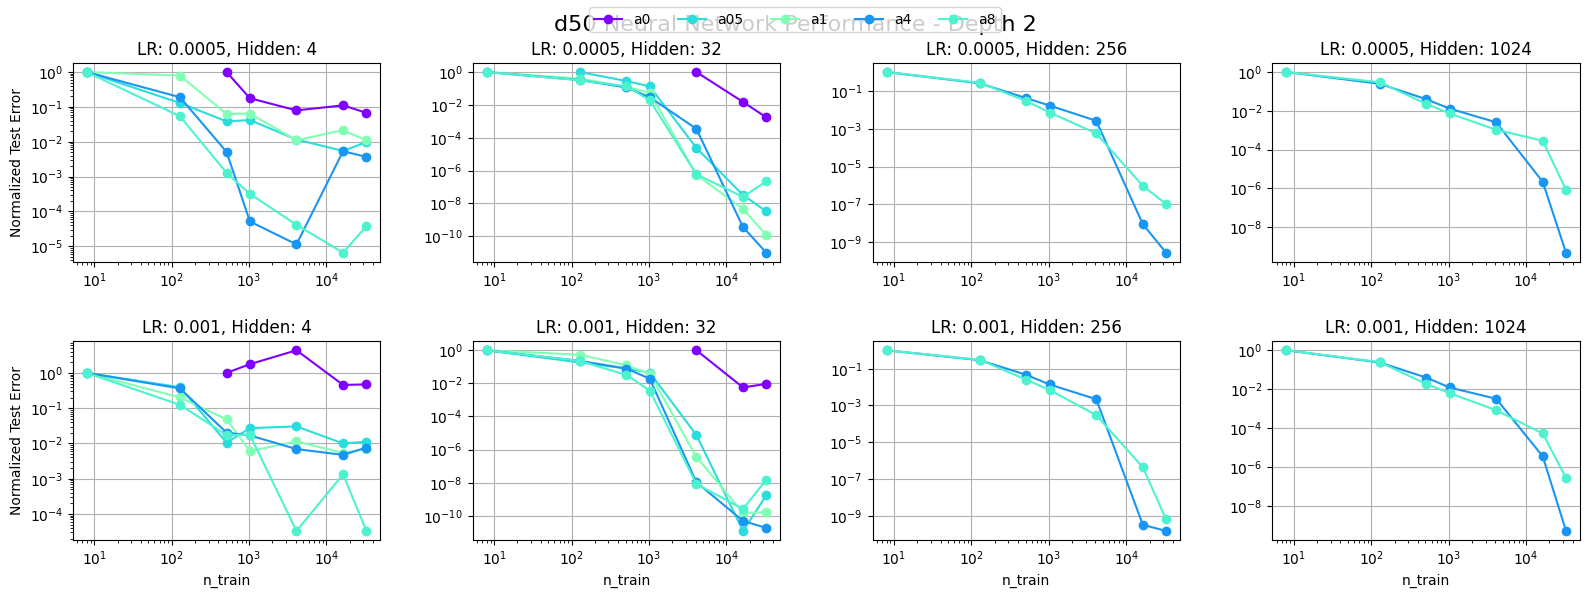

In [5]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl

# ======= USER SETTINGS =======
# Set the path to match the experiment name from the training script
results_directory = "/home/goring/TF_spectrum/results/results_correct_scaling/d16_mup_hidden4_d2_0303"

# If you want to save the figure, specify a file name (e.g., "my_plot.png"); otherwise, leave as an empty string.
save_fig_path = "d50_normal_hidden10_plot.png"  # Set a filename to save the figure

# Set to True to normalize all curves to 1 at the first point, False to use raw values
normalize_errors = True  # Toggle normalization on/off

# ======= LOAD RESULTS =======
def load_results(directory):
    """
    Load all JSON Lines files in the directory that match the pattern *_results_*.jsonl.
    Each line should be a JSON object corresponding to one experimental configuration.
    """
    pattern = os.path.join(directory, "results_*.jsonl")
    files = glob.glob(pattern)
    results = []
    for filename in files:
        with open(filename, "r") as f:
            for line in f:
                try:
                    data = json.loads(line)
                    results.append(data)
                except Exception as e:
                    print(f"Error parsing line in {filename}: {line}\nError: {e}")
    return results

# Load results
all_results = load_results(results_directory)

if not all_results:
    print("No results loaded. Please check the directory path.")

# ======= FILTER FOR SPECIFIC NETWORKS =======
# We'll filter by depth=2 as specified in the training script
filtered_results = [r for r in all_results if r.get("depth") == 2]

# ======= IDENTIFY UNIQUE PARAMETERS =======
lr_set = set()
hidden_set = set()
dataset_set = set()

# Extract unique parameters from results
for r in filtered_results:
    try:
        lr_set.add(r["learning_rate"])
        hidden_set.add(r["hidden_size"])
        dataset_set.add(r["dataset_name"])
    except KeyError as e:
        print(f"Missing key {e} in result: {r}")
        continue

# Use the unique values found in the results
unique_lr = sorted(lr_set)  # Should contain [0.0001, 0.001, 0.01]
unique_hidden = sorted(hidden_set)  # Should contain [10, 128, 256, 1024]
unique_dataset = sorted([d for d in dataset_set if d.startswith('a')])  # Should contain ["a20","a5","a2","a1","a05","a025","a0"]

# Select top 2 learning rates for comparison (or use a specific subset)
# You can modify this to select specific learning rates if needed
if len(unique_lr) >= 2:
    learning_rates_to_compare = unique_lr[:2]
    print(f"Comparing learning rates: {learning_rates_to_compare}")
else:
    learning_rates_to_compare = unique_lr
    print(f"Only one learning rate available: {learning_rates_to_compare}")

# ======= RAINBOW COLOR MAPPING =======
def create_dataset_colors(dataset_names):
    # Get only 'a' datasets
    a_datasets = [ds for ds in dataset_names if ds.startswith('a')]
    
    # Create color dictionary using rainbow colormap
    cmap = plt.get_cmap('rainbow')
    colors = {}
    
    # Define specific dataset order to match the training dataset names
    dataset_order = ['a0', 'a025', 'a05', 'a1', 'a2', 'a5', 'a20']
    
    # Assign colors based on position in dataset_order
    for i, dataset in enumerate(dataset_order):
        if dataset in a_datasets:
            # Distribute colors evenly across the rainbow
            colors[dataset] = cmap(i / (len(dataset_order) - 1))
    
    # For any dataset not in our predefined list
    for dataset in a_datasets:
        if dataset not in colors:
            # Try to extract number and position it in the spectrum
            try:
                # For datasets like 'a3' that might not be in our list
                num = float(dataset[1:])
                # Position between 0 and 20 (assuming a0 to a20 range)
                position = min(1.0, max(0.0, num / 20.0))
                colors[dataset] = cmap(position)
            except ValueError:
                # Default for unparseable datasets
                colors[dataset] = cmap(0.5)  # Middle of the rainbow
    
    return colors

# Create color dictionary
dataset_colors = create_dataset_colors(unique_dataset)

# ======= GROUP DATA =======
# Function to group data by parameters
def group_results(results):
    grouped = {}
    for lr in unique_lr:
        grouped[lr] = {}
        for hs in unique_hidden:
            grouped[lr][hs] = {}
    
    for r in results:
        try:
            lr = r["learning_rate"]
            hs = r["hidden_size"]
            dataset = r["dataset_name"]
            n_train = r["n_train"]
            test_error = r["test_error"]
        except KeyError as e:
            print(f"Skipping result due to missing key: {e}")
            continue
        
        if dataset not in unique_dataset:
            continue  # Skip datasets that aren't in the a0-a20 format
            
        if dataset not in grouped[lr][hs]:
            grouped[lr][hs][dataset] = {}
        if n_train not in grouped[lr][hs][dataset]:
            grouped[lr][hs][dataset][n_train] = []
        grouped[lr][hs][dataset][n_train].append(test_error)
    
    return grouped

# Group results
grouped_results = group_results(filtered_results)

# ======= PLOT THE RESULTS =======
# Create a grid of subplots: 
# - Each column is a different hidden size
# - Each row is a learning rate
n_rows = len(learning_rates_to_compare)
n_cols = len(unique_hidden)

# Adjust figure size based on number of subplots
if n_cols == 1:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6, 4 * n_rows), squeeze=False)
else:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), squeeze=False)

# Create a dictionary to store legend handles
legend_handles = {}

for i, lr in enumerate(learning_rates_to_compare):
    for j, hs in enumerate(unique_hidden):
        # Get the appropriate axis
        ax = axes[i, j]
        
        # Plot data for this learning rate and hidden size
        data_dict = grouped_results[lr][hs]
        if data_dict:
            for dataset, ntrain_dict in data_dict.items():
                n_train_sorted = sorted(ntrain_dict.keys())
                if not n_train_sorted:
                    continue
                
                x_vals = n_train_sorted
                y_means = []
                y_stds = []
                
                # Calculate means and standard deviations
                for n in n_train_sorted:
                    errors = ntrain_dict[n]
                    mean_error = sum(errors) / len(errors)
                    std_error = np.std(errors) if len(errors) > 1 else 0
                    y_means.append(mean_error)
                    y_stds.append(std_error)
                
                # Normalize errors if normalization is enabled
                first_mean = y_means[0] if y_means else 0
                if normalize_errors and y_means and first_mean > 0:
                    y_means = [err / first_mean for err in y_means]
                    y_stds = [std / first_mean for std in y_stds]
                
                # Get color from dataset colors
                color = dataset_colors.get(dataset, 'blue')
                
                # Plot the line
                line = ax.errorbar(
                    x_vals, y_means, yerr=y_stds,
                    linestyle='-', marker='o', color=color, 
                    label=f"{dataset}"
                )[0]
                
                # Store for legend
                legend_key = dataset
                if legend_key not in legend_handles:
                    legend_handles[legend_key] = line
        
        # Set scales, labels, title
        ax.set_xscale("log")
        # Set y-scale to log if normalizing (to see power laws better)
        if normalize_errors:
            ax.set_yscale("log")
        
        ax.set_title(f"LR: {lr}, Hidden: {hs}")
        ax.grid(True)
        
        # Only add x-label to bottom row
        if i == len(learning_rates_to_compare) - 1:
            ax.set_xlabel("n_train")
        
        # Add y-label to leftmost column
        if j == 0:
            y_label = "Normalized Test Error" if normalize_errors else "Test Error"
            ax.set_ylabel(y_label)

# Create a global legend above the subplots only if we have handles
if legend_handles:
    fig.legend(
        list(legend_handles.values()), 
        list(legend_handles.keys()), 
        loc="upper center", 
        ncol=min(len(legend_handles), 6)
    )

# Add a title with experiment information
plt.suptitle(f"d50 Neural Network Performance - Depth 2", fontsize=16)

# Adjust layout to make room for the title and legend
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(top=0.90, hspace=0.4, wspace=0.3)

# Save the figure if a path is specified
if save_fig_path:
    plt.savefig(save_fig_path, dpi=300, bbox_inches='tight')
    print("Figure saved to", save_fig_path)
else:
    plt.show()

Comparing learning rates: [0.0005, 0.001]
Figure saved to d50_normal_hidden10_plot.png


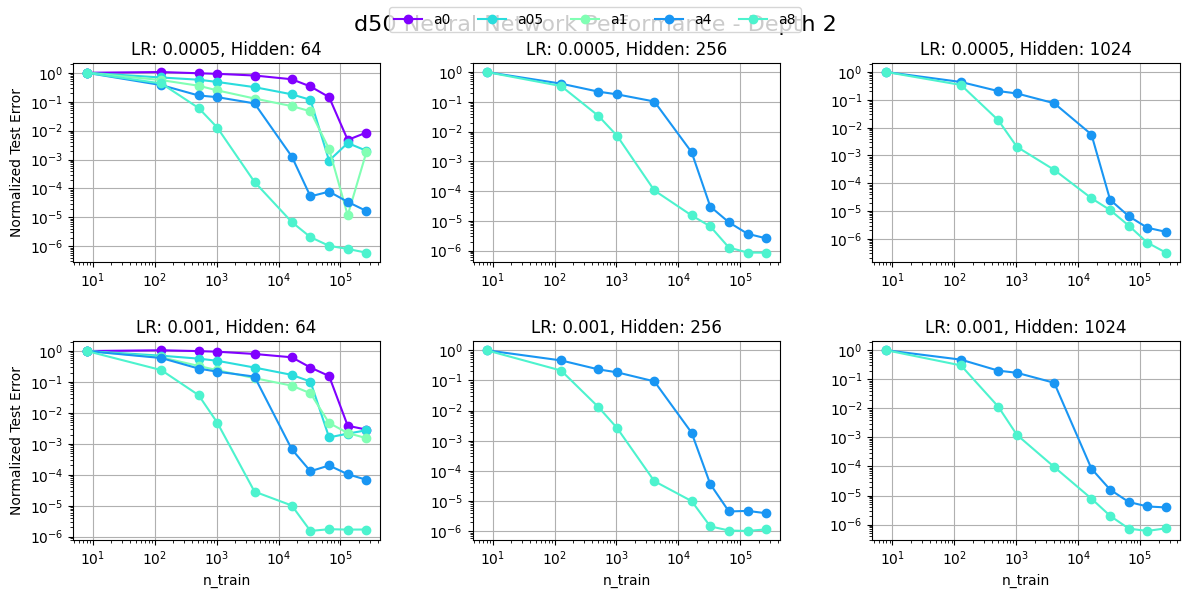

In [6]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl

# ======= USER SETTINGS =======
# Set the path to match the experiment name from the training script
results_directory = "/home/goring/TF_spectrum/results/results_correct_scaling/d16_mup_hidden64_d2_0303"

# If you want to save the figure, specify a file name (e.g., "my_plot.png"); otherwise, leave as an empty string.
save_fig_path = "d50_normal_hidden10_plot.png"  # Set a filename to save the figure

# Set to True to normalize all curves to 1 at the first point, False to use raw values
normalize_errors = True  # Toggle normalization on/off

# ======= LOAD RESULTS =======
def load_results(directory):
    """
    Load all JSON Lines files in the directory that match the pattern *_results_*.jsonl.
    Each line should be a JSON object corresponding to one experimental configuration.
    """
    pattern = os.path.join(directory, "results_*.jsonl")
    files = glob.glob(pattern)
    results = []
    for filename in files:
        with open(filename, "r") as f:
            for line in f:
                try:
                    data = json.loads(line)
                    results.append(data)
                except Exception as e:
                    print(f"Error parsing line in {filename}: {line}\nError: {e}")
    return results

# Load results
all_results = load_results(results_directory)

if not all_results:
    print("No results loaded. Please check the directory path.")

# ======= FILTER FOR SPECIFIC NETWORKS =======
# We'll filter by depth=2 as specified in the training script
filtered_results = [r for r in all_results if r.get("depth") == 2]

# ======= IDENTIFY UNIQUE PARAMETERS =======
lr_set = set()
hidden_set = set()
dataset_set = set()

# Extract unique parameters from results
for r in filtered_results:
    try:
        lr_set.add(r["learning_rate"])
        hidden_set.add(r["hidden_size"])
        dataset_set.add(r["dataset_name"])
    except KeyError as e:
        print(f"Missing key {e} in result: {r}")
        continue

# Use the unique values found in the results
unique_lr = sorted(lr_set)  # Should contain [0.0001, 0.001, 0.01]
unique_hidden = sorted(hidden_set)  # Should contain [10, 128, 256, 1024]
unique_dataset = sorted([d for d in dataset_set if d.startswith('a')])  # Should contain ["a20","a5","a2","a1","a05","a025","a0"]

# Select top 2 learning rates for comparison (or use a specific subset)
# You can modify this to select specific learning rates if needed
if len(unique_lr) >= 2:
    learning_rates_to_compare = unique_lr[:2]
    print(f"Comparing learning rates: {learning_rates_to_compare}")
else:
    learning_rates_to_compare = unique_lr
    print(f"Only one learning rate available: {learning_rates_to_compare}")

# ======= RAINBOW COLOR MAPPING =======
def create_dataset_colors(dataset_names):
    # Get only 'a' datasets
    a_datasets = [ds for ds in dataset_names if ds.startswith('a')]
    
    # Create color dictionary using rainbow colormap
    cmap = plt.get_cmap('rainbow')
    colors = {}
    
    # Define specific dataset order to match the training dataset names
    dataset_order = ['a0', 'a025', 'a05', 'a1', 'a2', 'a5', 'a20']
    
    # Assign colors based on position in dataset_order
    for i, dataset in enumerate(dataset_order):
        if dataset in a_datasets:
            # Distribute colors evenly across the rainbow
            colors[dataset] = cmap(i / (len(dataset_order) - 1))
    
    # For any dataset not in our predefined list
    for dataset in a_datasets:
        if dataset not in colors:
            # Try to extract number and position it in the spectrum
            try:
                # For datasets like 'a3' that might not be in our list
                num = float(dataset[1:])
                # Position between 0 and 20 (assuming a0 to a20 range)
                position = min(1.0, max(0.0, num / 20.0))
                colors[dataset] = cmap(position)
            except ValueError:
                # Default for unparseable datasets
                colors[dataset] = cmap(0.5)  # Middle of the rainbow
    
    return colors

# Create color dictionary
dataset_colors = create_dataset_colors(unique_dataset)

# ======= GROUP DATA =======
# Function to group data by parameters
def group_results(results):
    grouped = {}
    for lr in unique_lr:
        grouped[lr] = {}
        for hs in unique_hidden:
            grouped[lr][hs] = {}
    
    for r in results:
        try:
            lr = r["learning_rate"]
            hs = r["hidden_size"]
            dataset = r["dataset_name"]
            n_train = r["n_train"]
            test_error = r["test_error"]
        except KeyError as e:
            print(f"Skipping result due to missing key: {e}")
            continue
        
        if dataset not in unique_dataset:
            continue  # Skip datasets that aren't in the a0-a20 format
            
        if dataset not in grouped[lr][hs]:
            grouped[lr][hs][dataset] = {}
        if n_train not in grouped[lr][hs][dataset]:
            grouped[lr][hs][dataset][n_train] = []
        grouped[lr][hs][dataset][n_train].append(test_error)
    
    return grouped

# Group results
grouped_results = group_results(filtered_results)

# ======= PLOT THE RESULTS =======
# Create a grid of subplots: 
# - Each column is a different hidden size
# - Each row is a learning rate
n_rows = len(learning_rates_to_compare)
n_cols = len(unique_hidden)

# Adjust figure size based on number of subplots
if n_cols == 1:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6, 4 * n_rows), squeeze=False)
else:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), squeeze=False)

# Create a dictionary to store legend handles
legend_handles = {}

for i, lr in enumerate(learning_rates_to_compare):
    for j, hs in enumerate(unique_hidden):
        # Get the appropriate axis
        ax = axes[i, j]
        
        # Plot data for this learning rate and hidden size
        data_dict = grouped_results[lr][hs]
        if data_dict:
            for dataset, ntrain_dict in data_dict.items():
                n_train_sorted = sorted(ntrain_dict.keys())
                if not n_train_sorted:
                    continue
                
                x_vals = n_train_sorted
                y_means = []
                y_stds = []
                
                # Calculate means and standard deviations
                for n in n_train_sorted:
                    errors = ntrain_dict[n]
                    mean_error = sum(errors) / len(errors)
                    std_error = np.std(errors) if len(errors) > 1 else 0
                    y_means.append(mean_error)
                    y_stds.append(std_error)
                
                # Normalize errors if normalization is enabled
                first_mean = y_means[0] if y_means else 0
                if normalize_errors and y_means and first_mean > 0:
                    y_means = [err / first_mean for err in y_means]
                    y_stds = [std / first_mean for std in y_stds]
                
                # Get color from dataset colors
                color = dataset_colors.get(dataset, 'blue')
                
                # Plot the line
                line = ax.errorbar(
                    x_vals, y_means, yerr=y_stds,
                    linestyle='-', marker='o', color=color, 
                    label=f"{dataset}"
                )[0]
                
                # Store for legend
                legend_key = dataset
                if legend_key not in legend_handles:
                    legend_handles[legend_key] = line
        
        # Set scales, labels, title
        ax.set_xscale("log")
        # Set y-scale to log if normalizing (to see power laws better)
        if normalize_errors:
            ax.set_yscale("log")
        
        ax.set_title(f"LR: {lr}, Hidden: {hs}")
        ax.grid(True)
        
        # Only add x-label to bottom row
        if i == len(learning_rates_to_compare) - 1:
            ax.set_xlabel("n_train")
        
        # Add y-label to leftmost column
        if j == 0:
            y_label = "Normalized Test Error" if normalize_errors else "Test Error"
            ax.set_ylabel(y_label)

# Create a global legend above the subplots only if we have handles
if legend_handles:
    fig.legend(
        list(legend_handles.values()), 
        list(legend_handles.keys()), 
        loc="upper center", 
        ncol=min(len(legend_handles), 6)
    )

# Add a title with experiment information
plt.suptitle(f"d50 Neural Network Performance - Depth 2", fontsize=16)

# Adjust layout to make room for the title and legend
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(top=0.90, hspace=0.4, wspace=0.3)

# Save the figure if a path is specified
if save_fig_path:
    plt.savefig(save_fig_path, dpi=300, bbox_inches='tight')
    print("Figure saved to", save_fig_path)
else:
    plt.show()

Comparing learning rates: [0.0005, 0.001]
Figure saved to d50_normal_hidden10_plot.png


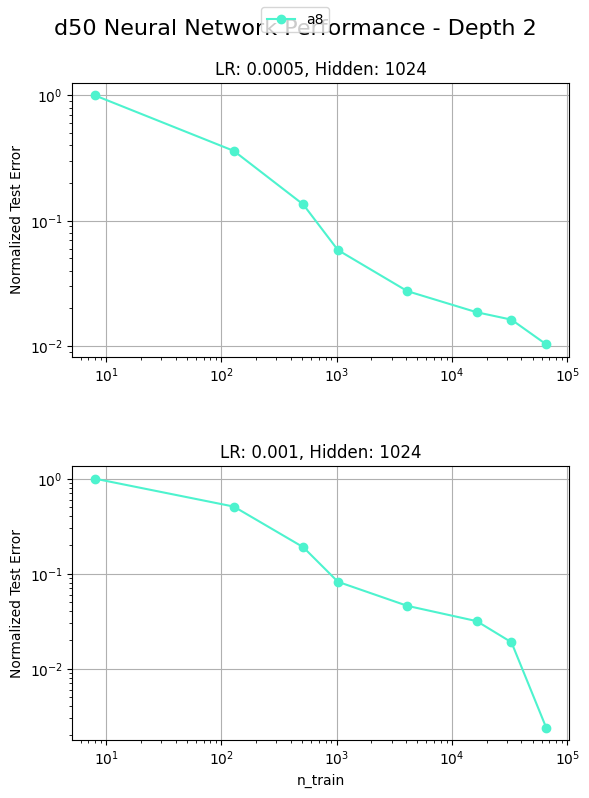

In [2]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl

# ======= USER SETTINGS =======
# Set the path to match the experiment name from the training script
results_directory = "/home/goring/TF_spectrum/results/results_correct_scaling/d16_standard_staircase_d2_0303"

# If you want to save the figure, specify a file name (e.g., "my_plot.png"); otherwise, leave as an empty string.
save_fig_path = "d50_normal_hidden10_plot.png"  # Set a filename to save the figure

# Set to True to normalize all curves to 1 at the first point, False to use raw values
normalize_errors = True  # Toggle normalization on/off

# ======= LOAD RESULTS =======
def load_results(directory):
    """
    Load all JSON Lines files in the directory that match the pattern *_results_*.jsonl.
    Each line should be a JSON object corresponding to one experimental configuration.
    """
    pattern = os.path.join(directory, "results_*.jsonl")
    files = glob.glob(pattern)
    results = []
    for filename in files:
        with open(filename, "r") as f:
            for line in f:
                try:
                    data = json.loads(line)
                    results.append(data)
                except Exception as e:
                    print(f"Error parsing line in {filename}: {line}\nError: {e}")
    return results

# Load results
all_results = load_results(results_directory)

if not all_results:
    print("No results loaded. Please check the directory path.")

# ======= FILTER FOR SPECIFIC NETWORKS =======
# We'll filter by depth=2 as specified in the training script
filtered_results = [r for r in all_results if r.get("depth") == 2]

# ======= IDENTIFY UNIQUE PARAMETERS =======
lr_set = set()
hidden_set = set()
dataset_set = set()

# Extract unique parameters from results
for r in filtered_results:
    try:
        lr_set.add(r["learning_rate"])
        hidden_set.add(r["hidden_size"])
        dataset_set.add(r["dataset_name"])
    except KeyError as e:
        print(f"Missing key {e} in result: {r}")
        continue

# Use the unique values found in the results
unique_lr = sorted(lr_set)  # Should contain [0.0001, 0.001, 0.01]
unique_hidden = sorted(hidden_set)  # Should contain [10, 128, 256, 1024]
unique_dataset = sorted([d for d in dataset_set if d.startswith('a')])  # Should contain ["a20","a5","a2","a1","a05","a025","a0"]

# Select top 2 learning rates for comparison (or use a specific subset)
# You can modify this to select specific learning rates if needed
if len(unique_lr) >= 2:
    learning_rates_to_compare = unique_lr[:2]
    print(f"Comparing learning rates: {learning_rates_to_compare}")
else:
    learning_rates_to_compare = unique_lr
    print(f"Only one learning rate available: {learning_rates_to_compare}")

# ======= RAINBOW COLOR MAPPING =======
def create_dataset_colors(dataset_names):
    # Get only 'a' datasets
    a_datasets = [ds for ds in dataset_names if ds.startswith('a')]
    
    # Create color dictionary using rainbow colormap
    cmap = plt.get_cmap('rainbow')
    colors = {}
    
    # Define specific dataset order to match the training dataset names
    dataset_order = ['a0', 'a025', 'a05', 'a1', 'a2', 'a5', 'a20']
    
    # Assign colors based on position in dataset_order
    for i, dataset in enumerate(dataset_order):
        if dataset in a_datasets:
            # Distribute colors evenly across the rainbow
            colors[dataset] = cmap(i / (len(dataset_order) - 1))
    
    # For any dataset not in our predefined list
    for dataset in a_datasets:
        if dataset not in colors:
            # Try to extract number and position it in the spectrum
            try:
                # For datasets like 'a3' that might not be in our list
                num = float(dataset[1:])
                # Position between 0 and 20 (assuming a0 to a20 range)
                position = min(1.0, max(0.0, num / 20.0))
                colors[dataset] = cmap(position)
            except ValueError:
                # Default for unparseable datasets
                colors[dataset] = cmap(0.5)  # Middle of the rainbow
    
    return colors

# Create color dictionary
dataset_colors = create_dataset_colors(unique_dataset)

# ======= GROUP DATA =======
# Function to group data by parameters
def group_results(results):
    grouped = {}
    for lr in unique_lr:
        grouped[lr] = {}
        for hs in unique_hidden:
            grouped[lr][hs] = {}
    
    for r in results:
        try:
            lr = r["learning_rate"]
            hs = r["hidden_size"]
            dataset = r["dataset_name"]
            n_train = r["n_train"]
            test_error = r["test_error"]
        except KeyError as e:
            print(f"Skipping result due to missing key: {e}")
            continue
        
        if dataset not in unique_dataset:
            continue  # Skip datasets that aren't in the a0-a20 format
            
        if dataset not in grouped[lr][hs]:
            grouped[lr][hs][dataset] = {}
        if n_train not in grouped[lr][hs][dataset]:
            grouped[lr][hs][dataset][n_train] = []
        grouped[lr][hs][dataset][n_train].append(test_error)
    
    return grouped

# Group results
grouped_results = group_results(filtered_results)

# ======= PLOT THE RESULTS =======
# Create a grid of subplots: 
# - Each column is a different hidden size
# - Each row is a learning rate
n_rows = len(learning_rates_to_compare)
n_cols = len(unique_hidden)

# Adjust figure size based on number of subplots
if n_cols == 1:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6, 4 * n_rows), squeeze=False)
else:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), squeeze=False)

# Create a dictionary to store legend handles
legend_handles = {}

for i, lr in enumerate(learning_rates_to_compare):
    for j, hs in enumerate(unique_hidden):
        # Get the appropriate axis
        ax = axes[i, j]
        
        # Plot data for this learning rate and hidden size
        data_dict = grouped_results[lr][hs]
        if data_dict:
            for dataset, ntrain_dict in data_dict.items():
                n_train_sorted = sorted(ntrain_dict.keys())
                if not n_train_sorted:
                    continue
                
                x_vals = n_train_sorted
                y_means = []
                y_stds = []
                
                # Calculate means and standard deviations
                for n in n_train_sorted:
                    errors = ntrain_dict[n]
                    mean_error = sum(errors) / len(errors)
                    std_error = np.std(errors) if len(errors) > 1 else 0
                    y_means.append(mean_error)
                    y_stds.append(std_error)
                
                # Normalize errors if normalization is enabled
                first_mean = y_means[0] if y_means else 0
                if normalize_errors and y_means and first_mean > 0:
                    y_means = [err / first_mean for err in y_means]
                    y_stds = [std / first_mean for std in y_stds]
                
                # Get color from dataset colors
                color = dataset_colors.get(dataset, 'blue')
                
                # Plot the line
                line = ax.errorbar(
                    x_vals, y_means, yerr=y_stds,
                    linestyle='-', marker='o', color=color, 
                    label=f"{dataset}"
                )[0]
                
                # Store for legend
                legend_key = dataset
                if legend_key not in legend_handles:
                    legend_handles[legend_key] = line
        
        # Set scales, labels, title
        ax.set_xscale("log")
        # Set y-scale to log if normalizing (to see power laws better)
        if normalize_errors:
            ax.set_yscale("log")
        
        ax.set_title(f"LR: {lr}, Hidden: {hs}")
        ax.grid(True)
        
        # Only add x-label to bottom row
        if i == len(learning_rates_to_compare) - 1:
            ax.set_xlabel("n_train")
        
        # Add y-label to leftmost column
        if j == 0:
            y_label = "Normalized Test Error" if normalize_errors else "Test Error"
            ax.set_ylabel(y_label)

# Create a global legend above the subplots only if we have handles
if legend_handles:
    fig.legend(
        list(legend_handles.values()), 
        list(legend_handles.keys()), 
        loc="upper center", 
        ncol=min(len(legend_handles), 6)
    )

# Add a title with experiment information
plt.suptitle(f"d50 Neural Network Performance - Depth 2", fontsize=16)

# Adjust layout to make room for the title and legend
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(top=0.90, hspace=0.4, wspace=0.3)

# Save the figure if a path is specified
if save_fig_path:
    plt.savefig(save_fig_path, dpi=300, bbox_inches='tight')
    print("Figure saved to", save_fig_path)
else:
    plt.show()

Loading results from /home/goring/TF_spectrum/results/biggrid2_0503/sweep_d16_H4_sweep_d16H8_sweep_d16H16_sweep_d16H32_sweep_d16H64_exp_20250306...
Found 32 result files
Loaded 2961 individual results
Processing results...
Processed data: 2961 entries

Data Summary:
Distribution Types: ['NE', 'NL', 'NP']
Alpha Values: [np.float64(0.0), np.float64(0.5), np.float64(1.0), np.float64(4.0), np.float64(8.0)]
Learning Rates: [np.float64(6e-05), np.float64(0.00012), np.float64(0.0006)]
Dataset Model Sizes (ordered): ['d16H4', 'd16H8', 'd16H16', 'd16H32', 'd16H64']
Training Sizes: [np.int64(10), np.int64(100), np.int64(1000), np.int64(10000), np.int64(50000)]
Order Values: [np.int64(1), np.int64(2), np.int64(3)]

Creating plots...
Found 3 unique learning rates: [np.float64(6e-05), np.float64(0.00012), np.float64(0.0006)]
Found 5 unique dataset model sizes (ordered): ['d16H4', 'd16H8', 'd16H16', 'd16H32', 'd16H64']
Found 5 unique alpha values: [np.float64(0.0), np.float64(0.5), np.float64(1.0), 

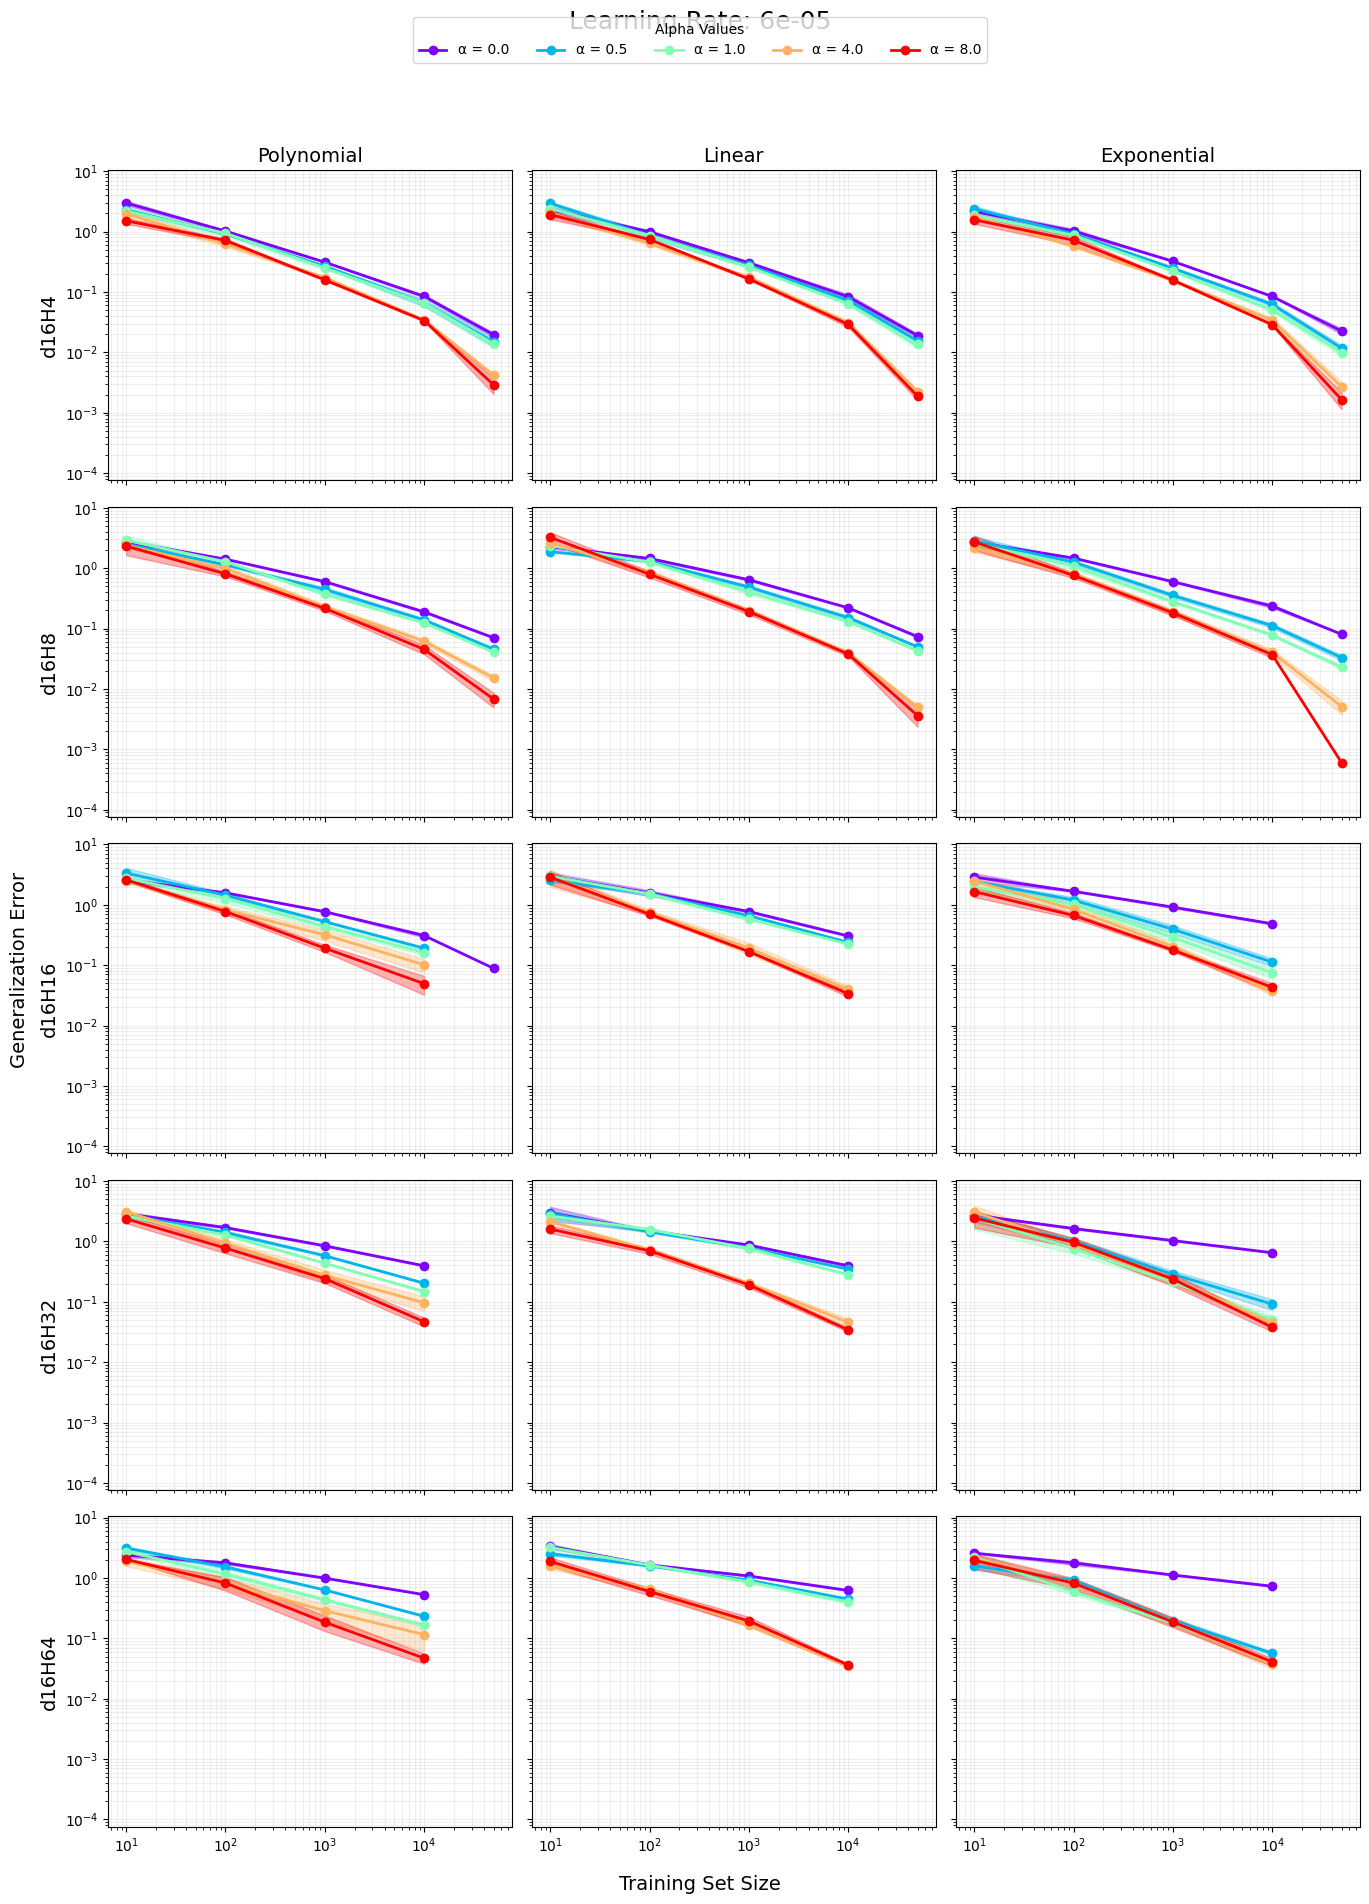

LR=0.00012, d16H4, NP, α=0.0:
    n_train  order  count
0        10      1      1
1        10      2      1
2        10      3      1
3       100      1      1
4       100      2      1
5       100      3      1
6      1000      1      1
7      1000      2      1
8      1000      3      1
9     10000      1      1
10    10000      2      1
11    10000      3      1
12    50000      1      1
13    50000      2      1
14    50000      3      1
LR=0.00012, d16H4, NP, α=0.5:
    n_train  order  count
0        10      1      1
1        10      2      1
2        10      3      1
3       100      1      1
4       100      2      1
5       100      3      1
6      1000      1      1
7      1000      2      1
8      1000      3      1
9     10000      1      1
10    10000      2      1
11    10000      3      1
12    50000      1      1
13    50000      2      1
14    50000      3      1
LR=0.00012, d16H4, NP, α=1.0:
    n_train  order  count
0        10      1      1
1        10      2      1


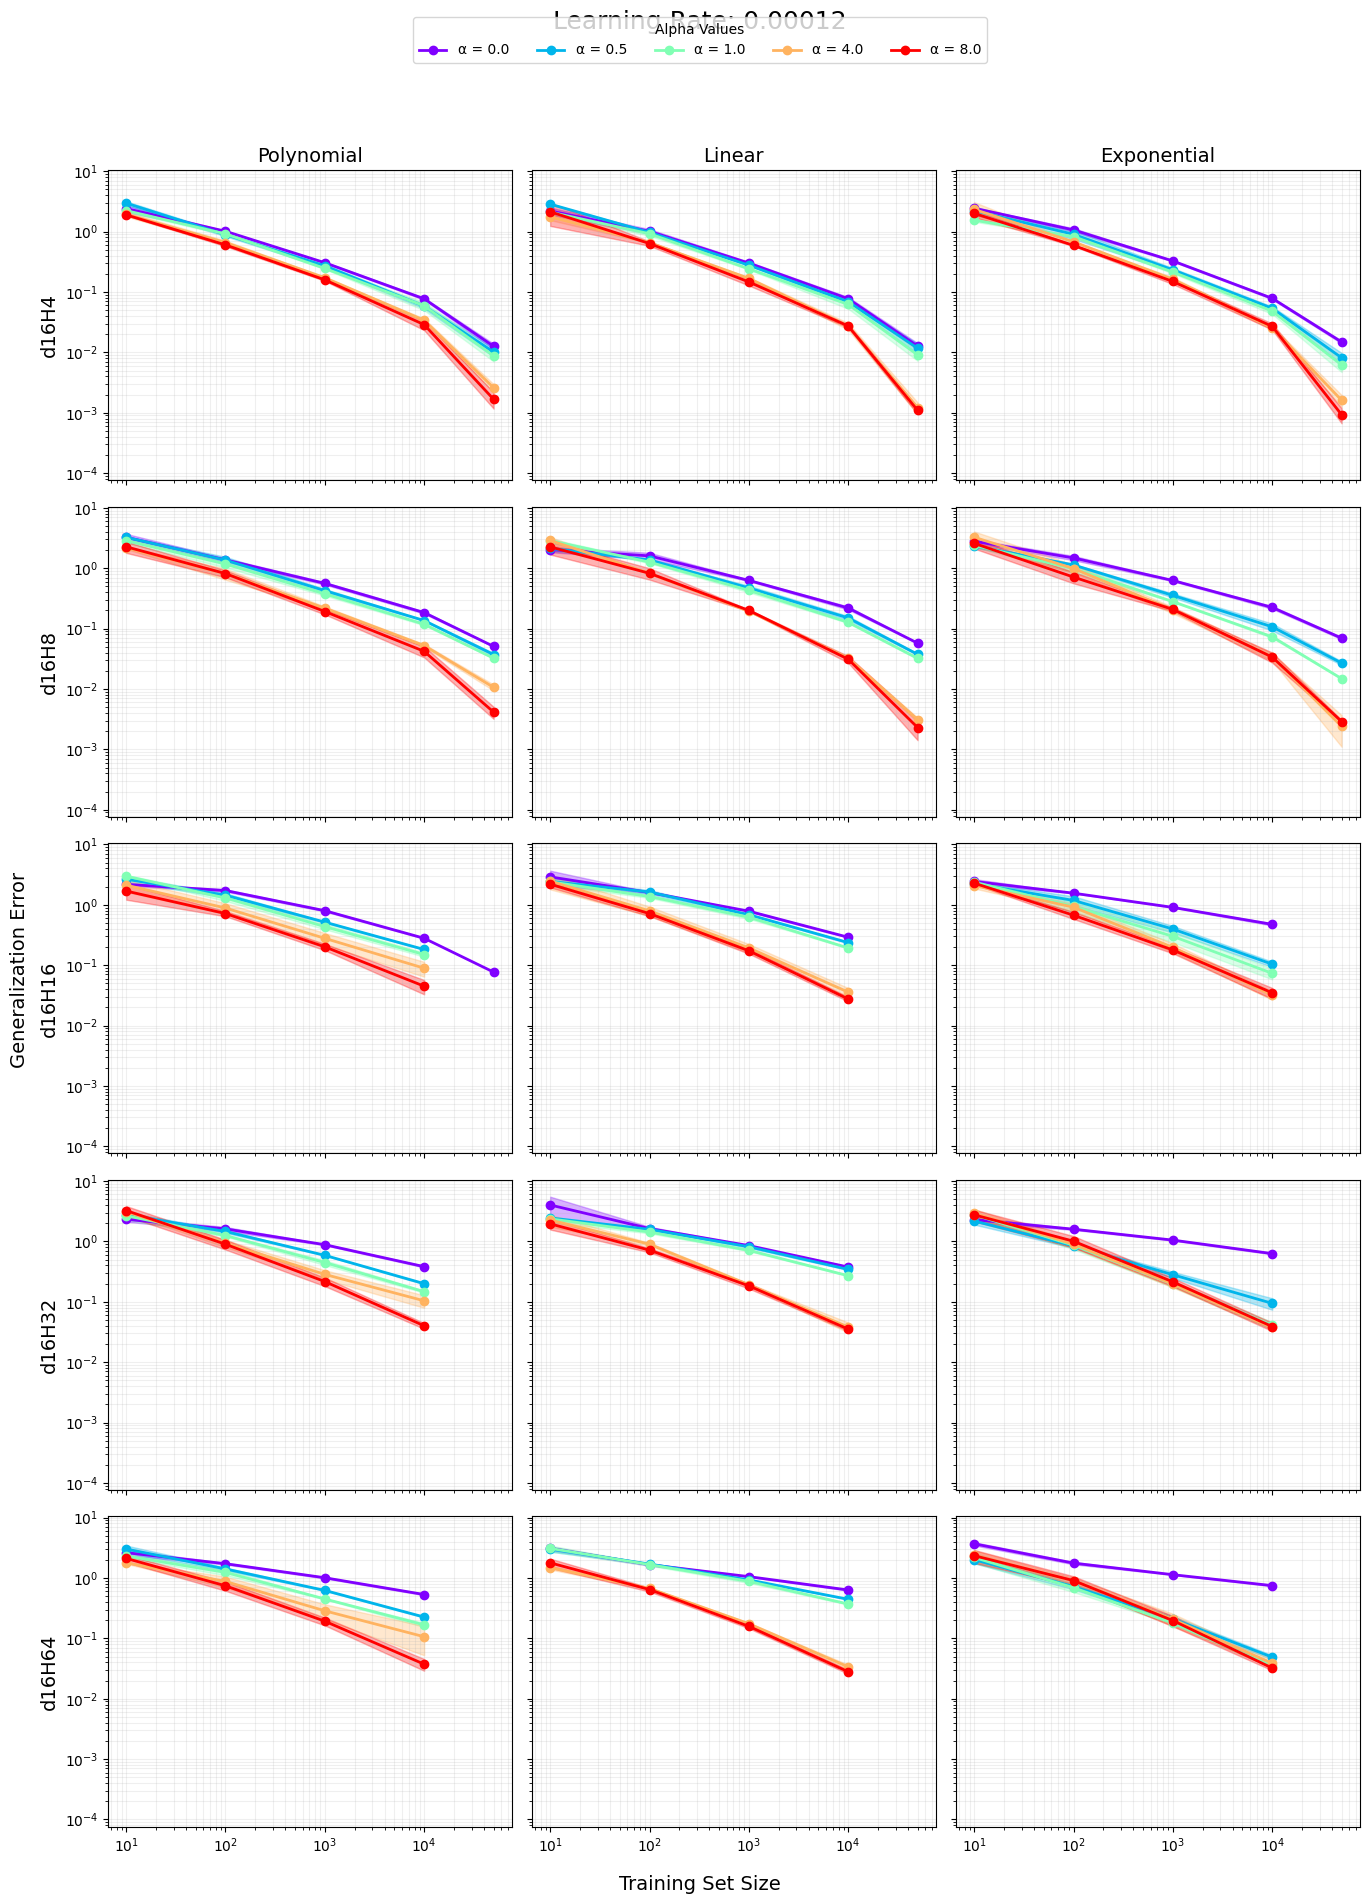

LR=0.0006, d16H4, NP, α=0.0:
    n_train  order  count
0        10      1      1
1        10      2      1
2        10      3      1
3       100      1      1
4       100      2      1
5       100      3      1
6      1000      1      1
7      1000      2      1
8      1000      3      1
9     10000      1      1
10    10000      2      1
11    10000      3      1
12    50000      1      1
13    50000      2      1
14    50000      3      1
LR=0.0006, d16H4, NP, α=0.5:
    n_train  order  count
0        10      1      1
1        10      2      1
2        10      3      1
3       100      1      1
4       100      2      1
5       100      3      1
6      1000      1      1
7      1000      2      1
8      1000      3      1
9     10000      1      1
10    10000      2      1
11    10000      3      1
12    50000      1      1
13    50000      2      1
14    50000      3      1
LR=0.0006, d16H4, NP, α=1.0:
    n_train  order  count
0        10      1      1
1        10      2      1
2  

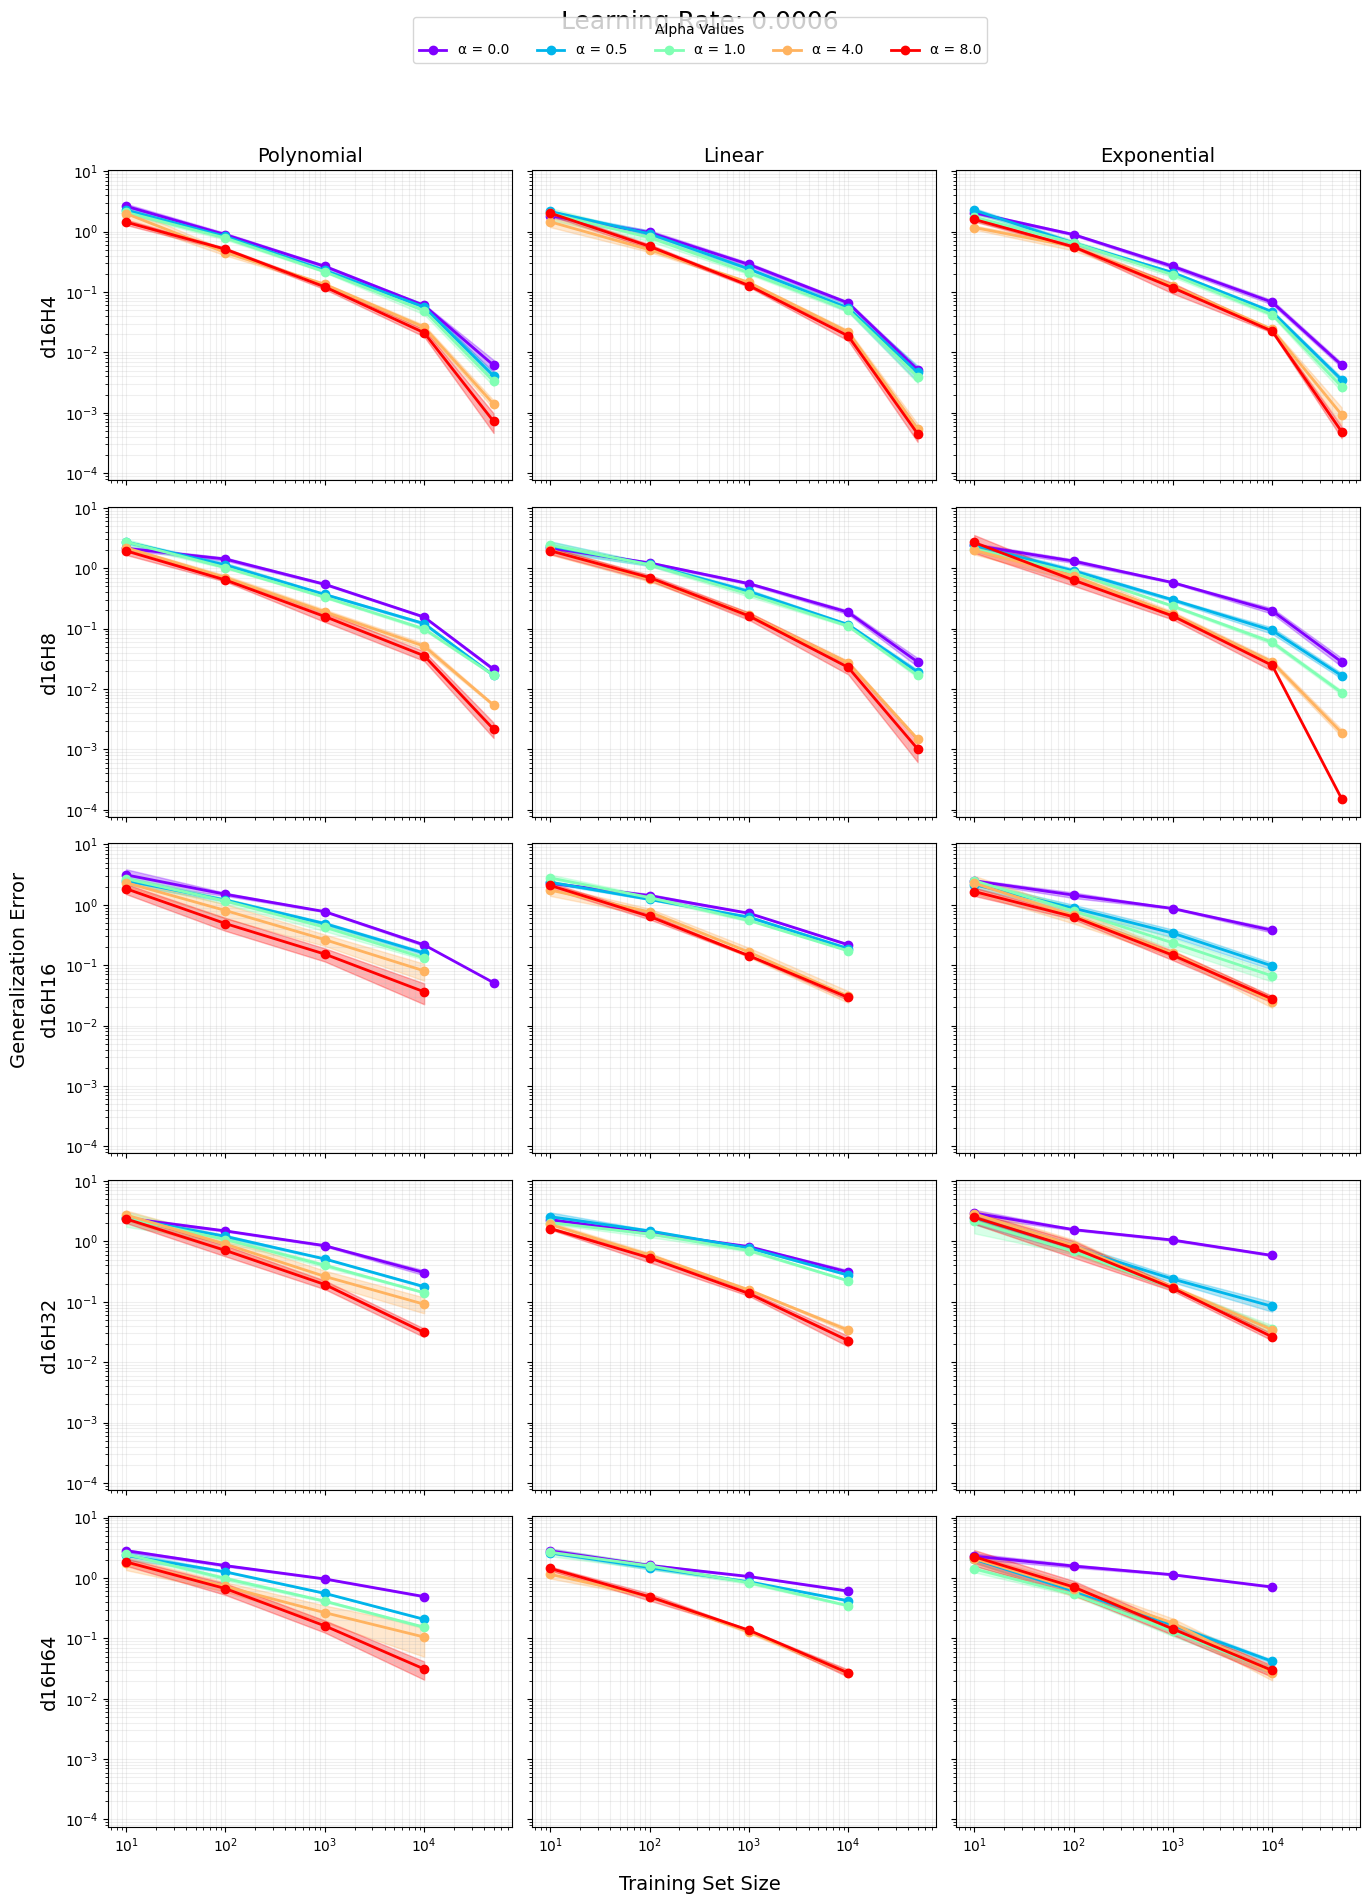

Done!


In [3]:
# Import necessary libraries
import os
import glob
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Configuration ===
# Set the path to your results directory
results_dir = "/home/goring/TF_spectrum/results/biggrid2_0503/sweep_d16_H4_sweep_d16H8_sweep_d16H16_sweep_d16H32_sweep_d16H64_exp_20250306"

# Set to True to save plots to files
save_plots = True
output_dir = "./result_plots"

# Create output directory if needed
if save_plots:
    os.makedirs(output_dir, exist_ok=True)

# === Load and Process Results ===
def load_results(results_dir):
    """Load all result files from the specified directory."""
    # Find all result files (both jsonl and json)
    result_files = glob.glob(os.path.join(results_dir, "**", "results_*.jsonl"), recursive=True)
    result_files += glob.glob(os.path.join(results_dir, "**", "final_results_*.json"), recursive=True)
    
    print(f"Found {len(result_files)} result files")
    
    all_results = []
    
    for file_path in result_files:
        try:
            # Check if it's a jsonl (line-delimited) file
            if file_path.endswith('.jsonl'):
                with open(file_path, 'r') as f:
                    for line in f:
                        if line.strip():  # Skip empty lines
                            try:
                                result = json.loads(line)
                                all_results.append(result)
                            except json.JSONDecodeError:
                                print(f"Error parsing JSON line in {file_path}")
            else:
                # Regular JSON file
                with open(file_path, 'r') as f:
                    data = json.load(f)
                    # Check if it's a list or a dictionary
                    if isinstance(data, list):
                        all_results.extend(data)
                    else:
                        all_results.append(data)
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    
    print(f"Loaded {len(all_results)} individual results")
    return all_results

def extract_info_from_result(result):
    """Extract key information from a result dictionary."""
    # Extract dataset information
    dataset_name = result.get('dataset_name', '')
    dataset_path = result.get('dataset_path', '')
    
    # Distribution type
    dist_type = None
    if dataset_name.startswith('NP_'):
        dist_type = 'NP'
    elif dataset_name.startswith('NL_'):
        dist_type = 'NL'
    elif dataset_name.startswith('NE_'):
        dist_type = 'NE'
    
    # If not found in dataset_name, try from path
    if dist_type is None:
        if 'biggrid_0403_poly' in dataset_path:
            dist_type = "NP"  # Polynomial
        elif 'biggrid_0403_lin' in dataset_path:
            dist_type = "NL"  # Linear
        elif 'biggrid_0403_exp' in dataset_path:
            dist_type = "NE"  # Exponential
    
    # Alpha value
    alpha = result.get('alpha')
    if alpha is None:
        # Try to extract from dataset_name
        alpha_match = re.search(r'a(\d+\.\d+)', dataset_name)
        if alpha_match:
            alpha = float(alpha_match.group(1))
    
    # Extract dataset model size (d16_H4, etc.)
    dataset_model_size = None
    model_h_size = None
    d_match = re.search(r'd(\d+)_H(\d+)', dataset_name)
    if d_match:
        input_dim = d_match.group(1)
        teacher_width = d_match.group(2)
        dataset_model_size = f"d{input_dim}H{teacher_width}"
        model_h_size = int(teacher_width)
    else:
        # Try from path
        path_match = re.search(r'PT_[A-Z]+_d(\d+)_H(\d+)', dataset_path)
        if path_match:
            input_dim = path_match.group(1)
            teacher_width = path_match.group(2)
            dataset_model_size = f"d{input_dim}H{teacher_width}"
            model_h_size = int(teacher_width)
    
    # Order (O_1, O_2, O_3)
    order = None
    order_match = re.search(r'O_(\d+)', dataset_path)
    if order_match:
        order = int(order_match.group(1))
    
    return {
        'distribution_type': dist_type,
        'alpha': alpha,
        'order': order,
        'learning_rate': result.get('learning_rate'),
        'n_train': result.get('n_train'),
        'test_error': result.get('test_error'),
        'dataset_model_size': dataset_model_size,
        'model_h_size': model_h_size  # Store numeric value for sorting
    }

def process_results(results):
    """Process results into a pandas DataFrame suitable for plotting."""
    processed_data = []
    
    for result in results:
        info = extract_info_from_result(result)
        processed_data.append(info)
    
    # Convert to DataFrame
    df = pd.DataFrame(processed_data)
    
    # Remove entries with missing values
    df = df.dropna(subset=['distribution_type', 'alpha', 'learning_rate', 'n_train', 'test_error', 'dataset_model_size'])
    
    return df

# Function to extract H value for sorting
def extract_h_value(model_size):
    match = re.search(r'H(\d+)', model_size)
    if match:
        return int(match.group(1))
    return 0

# === Plotting Functions ===
def create_grid_plots(df):
    """Create grid plots organized by learning rate, dataset model size, and distribution type."""
    # Get unique values for our grid dimensions
    learning_rates = sorted(df['learning_rate'].unique())
    
    # Get dataset model sizes and sort by numeric H value (d16H4, d16H8, d16H16, etc.)
    dataset_model_sizes = df['dataset_model_size'].unique().tolist()
    dataset_model_sizes.sort(key=extract_h_value)
    
    print(f"Found {len(learning_rates)} unique learning rates: {learning_rates}")
    print(f"Found {len(dataset_model_sizes)} unique dataset model sizes (ordered): {dataset_model_sizes}")
    
    # Define distribution type labels and order
    dist_types = ['NP', 'NL', 'NE']  # Order them as requested: Polynomial, Linear, Exponential
    dist_labels = {
        'NP': 'Polynomial',
        'NL': 'Linear',
        'NE': 'Exponential'
    }
    
    # Rainbow colormap for alpha values
    alpha_values = sorted(df['alpha'].unique())
    print(f"Found {len(alpha_values)} unique alpha values: {alpha_values}")
    colors = plt.cm.rainbow(np.linspace(0, 1, len(alpha_values)))
    
    # Find global y-axis limits for consistency across plots
    global_min_error = df['test_error'].min() * 0.5  # Give some extra space at the bottom
    global_max_error = df['test_error'].max() * 1.5  # Give some extra space at the top
    
    # For each learning rate, create a grid of plots
    for lr in learning_rates:
        # Filter data for this learning rate
        lr_df = df[df['learning_rate'] == lr]
        
        # Skip if no data for this learning rate
        if lr_df.empty:
            print(f"No data for learning rate {lr}, skipping")
            continue
        
        # Create a figure with a grid of subplots (dataset_model_sizes x dist_types)
        n_rows = len(dataset_model_sizes)
        n_cols = len(dist_types)
        
        # Create figure with the right size - scale based on number of plots
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4), 
                                sharex=True, sharey=True, squeeze=False)
        
        fig.suptitle(f'Learning Rate: {lr}', fontsize=18)
        
        # Add a common xlabel and ylabel
        fig.text(0.5, 0.04, 'Training Set Size', ha='center', fontsize=14)
        fig.text(0.04, 0.5, 'Generalization Error', va='center', rotation='vertical', fontsize=14)
        
        # For each position in the grid
        for row_idx, model_size in enumerate(dataset_model_sizes):
            for col_idx, dist_type in enumerate(dist_types):
                ax = axes[row_idx, col_idx]
                
                # Set title for each subplot
                if row_idx == 0:
                    ax.set_title(f'{dist_labels[dist_type]}', fontsize=14)
                
                # Add y-axis label for first column
                if col_idx == 0:
                    ax.set_ylabel(f'{model_size}', fontsize=14)
                
                # Set log scales
                ax.set_xscale('log')
                ax.set_yscale('log')
                
                # Filter data for this model size and distribution type
                plot_df = lr_df[(lr_df['dataset_model_size'] == model_size) & 
                                (lr_df['distribution_type'] == dist_type)]
                
                # For each alpha value, plot a line
                for j, alpha in enumerate(alpha_values):
                    alpha_df = plot_df[plot_df['alpha'] == alpha]
                    
                    # Skip if no data for this alpha
                    if alpha_df.empty:
                        continue
                    
                    # Group by n_train and calculate mean and standard error
                    # Note: We're averaging over ALL orders (O1, O2, O3)
                    grouped = alpha_df.groupby('n_train')['test_error'].agg(['mean', 'std', 'count']).reset_index()
                    
                    # Calculate standard error for ribbon plot
                    grouped['se'] = grouped['std'] / np.sqrt(grouped['count'])
                    
                    # Sort by n_train for proper line plotting
                    grouped = grouped.sort_values('n_train')
                    
                    # Print summary of what we're averaging over
                    order_counts = alpha_df.groupby(['n_train', 'order']).size().reset_index(name='count')
                    print(f"LR={lr}, {model_size}, {dist_type}, α={alpha}:")
                    print(order_counts)
                    
                    # Plot the line
                    line = ax.plot(grouped['n_train'], grouped['mean'], 'o-', 
                             color=colors[j], label=f'α = {alpha}',
                             markersize=6, linewidth=2)
                    
                    # Add ribbon (error band) - this visualizes variance of the mean
                    ax.fill_between(grouped['n_train'], 
                                    grouped['mean'] - grouped['se'], 
                                    grouped['mean'] + grouped['se'], 
                                    color=colors[j], alpha=0.3)
                
                # Set grid
                ax.grid(True, which="both", ls="-", alpha=0.2)
                
                # Set consistent y-axis limits across all plots
                ax.set_ylim(global_min_error, global_max_error)
        
        # Add a single legend for the whole figure
        handles, labels = axes[0, 0].get_legend_handles_labels()
        if handles:  # Only create legend if we have plotted data
            fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98),
                      ncol=min(len(alpha_values), 5), title="Alpha Values")
        
        plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])  # Adjust for the common x and y labels
        plt.subplots_adjust(top=0.9)  # Make room for the suptitle
        
        # Save figure if specified
        if save_plots:
            save_path = os.path.join(output_dir, f'lr_{lr}_grid.png')
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Saved plot to {save_path}")
        
        plt.show()

# === Execute the Analysis ===
print(f"Loading results from {results_dir}...")
results = load_results(results_dir)

print("Processing results...")
df = process_results(results)
print(f"Processed data: {len(df)} entries")

# Print summary of data
print("\nData Summary:")
print(f"Distribution Types: {sorted(df['distribution_type'].unique())}")
print(f"Alpha Values: {sorted(df['alpha'].unique())}")
print(f"Learning Rates: {sorted(df['learning_rate'].unique())}")
print(f"Dataset Model Sizes (ordered): {sorted(df['dataset_model_size'].unique(), key=extract_h_value)}")
print(f"Training Sizes: {sorted(df['n_train'].unique())}")
print(f"Order Values: {sorted(df['order'].unique())}")

# Create plots
print("\nCreating plots...")
create_grid_plots(df)
print("Done!")

In [ ]:
# Import necessary libraries
import os
import glob
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Configuration ===
# Set the path to your results directory
results_dir = "/home/goring/TF_spectrum/results/biggrid_finetune_standard_Hvary_0603"

# Set to True to save plots to files
save_plots = True
output_dir = "./result_plots_by_width"

# Create output directory if needed
if save_plots:
    os.makedirs(output_dir, exist_ok=True)

# === Load and Process Results ===
def load_results(results_dir):
    """Load all result files from the specified directory."""
    # Find all result files (both jsonl and json)
    result_files = glob.glob(os.path.join(results_dir, "**", "results_*.jsonl"), recursive=True)
    result_files += glob.glob(os.path.join(results_dir, "**", "final_results_*.json"), recursive=True)
    
    print(f"Found {len(result_files)} result files")
    
    all_results = []
    
    for file_path in result_files:
        try:
            # Check if it's a jsonl (line-delimited) file
            if file_path.endswith('.jsonl'):
                with open(file_path, 'r') as f:
                    for line in f:
                        if line.strip():  # Skip empty lines
                            try:
                                result = json.loads(line)
                                all_results.append(result)
                            except json.JSONDecodeError:
                                print(f"Error parsing JSON line in {file_path}")
            else:
                # Regular JSON file
                with open(file_path, 'r') as f:
                    data = json.load(f)
                    # Check if it's a list or a dictionary
                    if isinstance(data, list):
                        all_results.extend(data)
                    else:
                        all_results.append(data)
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    
    print(f"Loaded {len(all_results)} individual results")
    return all_results

def extract_info_from_result(result):
    """Extract key information from a result dictionary."""
    # Extract dataset information
    dataset_name = result.get('dataset_name', '')
    dataset_path = result.get('dataset_path', '')
    
    # Distribution type
    dist_type = None
    if dataset_name.startswith('NP_'):
        dist_type = 'NP'
    elif dataset_name.startswith('NL_'):
        dist_type = 'NL'
    elif dataset_name.startswith('NE_'):
        dist_type = 'NE'
    
    # If not found in dataset_name, try from path
    if dist_type is None:
        if 'biggrid_0403_poly' in dataset_path:
            dist_type = "NP"  # Polynomial
        elif 'biggrid_0403_lin' in dataset_path:
            dist_type = "NL"  # Linear
        elif 'biggrid_0403_exp' in dataset_path:
            dist_type = "NE"  # Exponential
    
    # Alpha value
    alpha = result.get('alpha')
    if alpha is None:
        # Try to extract from dataset_name
        alpha_match = re.search(r'a(\d+\.\d+)', dataset_name)
        if alpha_match:
            alpha = float(alpha_match.group(1))
    
    # Extract dataset model size (d16_H4, etc.)
    dataset_model_size = None
    model_h_size = None
    d_match = re.search(r'd(\d+)_H(\d+)', dataset_name)
    if d_match:
        input_dim = d_match.group(1)
        teacher_width = d_match.group(2)
        dataset_model_size = f"d{input_dim}H{teacher_width}"
        model_h_size = int(teacher_width)
    else:
        # Try from path
        path_match = re.search(r'PT_[A-Z]+_d(\d+)_H(\d+)', dataset_path)
        if path_match:
            input_dim = path_match.group(1)
            teacher_width = path_match.group(2)
            dataset_model_size = f"d{input_dim}H{teacher_width}"
            model_h_size = int(teacher_width)
    
    # Order (O_1, O_2, O_3)
    order = None
    order_match = re.search(r'O_(\d+)', dataset_path)
    if order_match:
        order = int(order_match.group(1))
    
    # Extract student hidden width
    hidden_size = result.get('hidden_size')
    
    return {
        'distribution_type': dist_type,
        'alpha': alpha,
        'order': order,
        'learning_rate': result.get('learning_rate'),
        'n_train': result.get('n_train'),
        'test_error': result.get('test_error'),
        'dataset_model_size': dataset_model_size,
        'model_h_size': model_h_size,  # Store numeric value for sorting
        'hidden_size': hidden_size     # Student network width 
    }

def process_results(results):
    """Process results into a pandas DataFrame suitable for plotting."""
    processed_data = []
    
    for result in results:
        info = extract_info_from_result(result)
        processed_data.append(info)
    
    # Convert to DataFrame
    df = pd.DataFrame(processed_data)
    
    # Remove entries with missing values
    df = df.dropna(subset=['distribution_type', 'alpha', 'n_train', 'test_error', 'dataset_model_size', 'hidden_size'])
    
    return df

# Function to extract H value for sorting
def extract_h_value(model_size):
    match = re.search(r'H(\d+)', model_size)
    if match:
        return int(match.group(1))
    return 0

# === Plotting Functions ===
def create_grid_plots(df):
    """Create grid plots organized by hidden size, dataset model size, and distribution type."""
    # Get unique values for our grid dimensions
    hidden_sizes = sorted(df['hidden_size'].unique())
    
    # Get dataset model sizes and sort by numeric H value (d16H4, d16H8, d16H16, etc.)
    dataset_model_sizes = df['dataset_model_size'].unique().tolist()
    dataset_model_sizes.sort(key=extract_h_value)
    
    print(f"Found {len(hidden_sizes)} unique hidden sizes: {hidden_sizes}")
    print(f"Found {len(dataset_model_sizes)} unique dataset model sizes (ordered): {dataset_model_sizes}")
    
    # Define distribution type labels and order
    dist_types = ['NP', 'NL', 'NE']  # Order them as requested: Polynomial, Linear, Exponential
    dist_labels = {
        'NP': 'Polynomial',
        'NL': 'Linear',
        'NE': 'Exponential'
    }
    
    # Rainbow colormap for alpha values
    alpha_values = sorted(df['alpha'].unique())
    print(f"Found {len(alpha_values)} unique alpha values: {alpha_values}")
    colors = plt.cm.rainbow(np.linspace(0, 1, len(alpha_values)))
    
    # Find global y-axis limits for consistency across plots
    global_min_error = df['test_error'].min() * 0.5  # Give some extra space at the bottom
    global_max_error = df['test_error'].max() * 1.5  # Give some extra space at the top
    
    # For each hidden size, create a grid of plots
    for hidden_size in hidden_sizes:
        # Filter data for this hidden size
        width_df = df[df['hidden_size'] == hidden_size]
        
        # Skip if no data for this hidden size
        if width_df.empty:
            print(f"No data for hidden width {hidden_size}, skipping")
            continue
        
        # Create a figure with a grid of subplots (dataset_model_sizes x dist_types)
        n_rows = len(dataset_model_sizes)
        n_cols = len(dist_types)
        
        # Create figure with the right size - scale based on number of plots
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4), 
                                sharex=True, sharey=True, squeeze=False)
        
        fig.suptitle(f'Student Hidden Width: {hidden_size}', fontsize=18)
        
        # Add a common xlabel and ylabel
        fig.text(0.5, 0.04, 'Training Set Size', ha='center', fontsize=14)
        fig.text(0.04, 0.5, 'Generalization Error', va='center', rotation='vertical', fontsize=14)
        
        # For each position in the grid
        for row_idx, model_size in enumerate(dataset_model_sizes):
            for col_idx, dist_type in enumerate(dist_types):
                ax = axes[row_idx, col_idx]
                
                # Set title for each subplot
                if row_idx == 0:
                    ax.set_title(f'{dist_labels[dist_type]}', fontsize=14)
                
                # Add y-axis label for first column
                if col_idx == 0:
                    ax.set_ylabel(f'{model_size}', fontsize=14)
                
                # Set log scales
                ax.set_xscale('log')
                ax.set_yscale('log')
                
                # Filter data for this model size and distribution type
                plot_df = width_df[(width_df['dataset_model_size'] == model_size) & 
                                  (width_df['distribution_type'] == dist_type)]
                
                # For each alpha value, plot a line
                for j, alpha in enumerate(alpha_values):
                    alpha_df = plot_df[plot_df['alpha'] == alpha]
                    
                    # Skip if no data for this alpha
                    if alpha_df.empty:
                        continue
                    
                    # Group by n_train and calculate mean and standard error
                    # Averaging over ALL orders (O1, O2, O3)
                    grouped = alpha_df.groupby('n_train')['test_error'].agg(['mean', 'std', 'count']).reset_index()
                    
                    # Calculate standard error for ribbon plot
                    grouped['se'] = grouped['std'] / np.sqrt(grouped['count'])
                    
                    # Sort by n_train for proper line plotting
                    grouped = grouped.sort_values('n_train')
                    
                    # Print summary of what we're averaging over
                    order_counts = alpha_df.groupby(['n_train', 'order']).size().reset_index(name='count')
                    print(f"Width={hidden_size}, {model_size}, {dist_type}, α={alpha}:")
                    print(order_counts)
                    
                    # Plot the line
                    line = ax.plot(grouped['n_train'], grouped['mean'], 'o-', 
                             color=colors[j], label=f'α = {alpha}',
                             markersize=6, linewidth=2)
                    
                    # Add ribbon (error band) - this visualizes variance of the mean
                    ax.fill_between(grouped['n_train'], 
                                    grouped['mean'] - grouped['se'], 
                                    grouped['mean'] + grouped['se'], 
                                    color=colors[j], alpha=0.3)
                
                # Set grid
                ax.grid(True, which="both", ls="-", alpha=0.2)
                
                # Set consistent y-axis limits across all plots
                ax.set_ylim(global_min_error, global_max_error)
        
        # Add a single legend for the whole figure
        handles, labels = axes[0, 0].get_legend_handles_labels()
        if handles:  # Only create legend if we have plotted data
            fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98),
                      ncol=min(len(alpha_values), 5), title="Alpha Values")
        
        plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])  # Adjust for the common x and y labels
        plt.subplots_adjust(top=0.9)  # Make room for the suptitle
        
        # Save figure if specified
        if save_plots:
            save_path = os.path.join(output_dir, f'width_{hidden_size}_grid.png')
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Saved plot to {save_path}")
        
        plt.show()

# === Execute the Analysis ===
print(f"Loading results from {results_dir}...")
results = load_results(results_dir)

print("Processing results...")
df = process_results(results)
print(f"Processed data: {len(df)} entries")

# Print summary of data
print("\nData Summary:")
print(f"Distribution Types: {sorted(df['distribution_type'].unique())}")
print(f"Alpha Values: {sorted(df['alpha'].unique())}")
print(f"Hidden Sizes: {sorted(df['hidden_size'].unique())}")
print(f"Dataset Model Sizes (ordered): {sorted(df['dataset_model_size'].unique(), key=extract_h_value)}")
print(f"Training Sizes: {sorted(df['n_train'].unique())}")
print(f"Order Values: {sorted(df['order'].unique() if 'order' in df.columns else [])}")

# Create plots
print("\nCreating plots...")
create_grid_plots(df)
print("Done!")

Loading results from /home/goring/TF_spectrum/results/biggrid_finetune_standard_Hvary_0603...
Found 32 result files
Loaded 2627 individual results
Processing results...
Processed data: 2627 entries

Data Summary:
Distribution Types: ['NE', 'NL', 'NP']
Alpha Values: [np.float64(0.0), np.float64(0.5), np.float64(1.0), np.float64(4.0), np.float64(8.0)]
Hidden Sizes: [np.int64(512), np.int64(1024), np.int64(2048)]
Dataset Model Sizes (ordered): ['d16H4', 'd16H8', 'd16H16', 'd16H32', 'd16H64']
Training Sizes: [np.int64(10), np.int64(100), np.int64(1000), np.int64(10000), np.int64(50000)]
Order Values: [np.int64(1), np.int64(2), np.int64(3)]

Creating plots...
Found 3 unique hidden sizes: [np.int64(512), np.int64(1024), np.int64(2048)]
Found 5 unique dataset model sizes (ordered): ['d16H4', 'd16H8', 'd16H16', 'd16H32', 'd16H64']
Found 5 unique alpha values: [np.float64(0.0), np.float64(0.5), np.float64(1.0), np.float64(4.0), np.float64(8.0)]
Width=512, d16H4, NP, α=0.0:
    n_train  order  c